# Proto-CLIP with Generalized Von Mises-Fisher loss

#### Deep Learning Project (2025), Università degli Studi di Trento 

**Authors:**

- Sebastiano Tocci - 257842
- Marco Ragusa - 258336
- Alessandro Sartore - 256152

## Abstract

We study base-to-novel generalization on Oxford Flowers102 in a few-shot setting, where we adapt using only 10 images per Base class from the training split, and Novel classes remain unseen during training. We use CLIP ViT-B/16 as a frozen vision-language backbone and train lightweight classification heads on top of normalized CLIP image embeddings.

Starting from a prototype-based Proto-CLIP [[3](https://arxiv.org/abs/2307.03073)] head, we introduce the von Mises-Fisher (vMF) loss formulation and the prototype-dispersion regularizer from SphOR [[1](https://arxiv.org/abs/2503.08049)] to improve class separation on the hypersphere. Following the same reference, we add a confidence-based rejection mechanism that falls back to zero-shot CLIP when the adapted head is uncertain, improving robustness on Novel classes. We also evaluate the effect of Mix-Up augmentation as done by Bahavan et al [[1](https://arxiv.org/abs/2503.08049)].

Our best configuration (vMF Proto-CLIP + augmentation + rejection) achieves Base = 87.18%, Novel = 77.42%, HM = 82.01%. A full comparison is provided in the Results summary section.

---

## Key contributions

- End-to-end reimplementation of Proto-CLIP [[3](https://arxiv.org/abs/2307.03073)] with a frozen CLIP backbone and a lightweight prototype-based head.
- Integration of the vMF-based spherical loss from SphOR [[1](https://arxiv.org/abs/2503.08049)] and a prototype dispersion regularizer to improve the Base-Novel trade off.
- Inference-time confidence rejection with class-specific thresholds estimated on `train_base` (correct predictions), enabling a CLIP fallback for low-confidence outputs.
- Attempted to separate class prototypes using a Bhattacharyya-distance overlap metric rather than plain cosine similarity; abandoned due to numerical instability in 256D embeddings.
- Targeted ablations and augmentation study to identify the components that contribute most to the final harmonic mean.

## Problem setup and evaluation protocol

We use Oxford Flowers102 with Base classes (IDs 0-50) and Novel classes (IDs 51-101). We train on the provided 10-shot Base training split, and evaluate separately on `test_base` and `test_novel`. We report Top-1 accuracy on Base and Novel subsets and their harmonic mean:

$$
\mathrm{HM}=\frac{2\,\mathrm{Acc}_{\mathcal{B}}\,\mathrm{Acc}_{\mathcal{N}}}{\mathrm{Acc}_{\mathcal{B}}+\mathrm{Acc}_{\mathcal{N}}}.
$$

### Models considered

We compare predictors built on a frozen CLIP backbone:

- **Zero-shot CLIP** baseline (no training).
- **Proto-CLIP** prototype/cache head (`OriginalProtoClip`).
- **vMF heads** (`vMFSLProtoClip`) with an optional prototype dispersion regularizer, plus ablations.
- **Confidence-based rejection** (optional): class-specific thresholds estimated on `train_base` to fall back to zero-shot CLIP under low confidence.
- **Augmentation variants** and the final **Ultimate vMF Proto-CLIP** configuration.

---

### CLIP ViT-B/16 zero-shot baseline
We report the zero-shot CLIP baseline provided in the project assignment document. 

| Model | Base Top-1 | Novel Top-1 | Harmonic Mean |
|---|---:|---:|---:|
| CLIP ViT-B/16 | 71.33% | 78.24% | 74.62% |


## Imports, logging, and CLIP initialization

We import the required libraries, configure logging/warning verbosity, select the compute device, and load the CLIP ViT-B/16 backbone with its preprocessing pipeline.


In [ ]:
# Core deep learning libraries
%pip install -q torch torchvision openai_clip tqdm numpy Pillow scipy ftfy regex pytorch-lightning scikit-learn &> /dev/null

In [ ]:
# ==================== IMPORTS AND BASIC SETUP ====================
import torch
import torchvision.transforms as T
import clip
from tqdm import tqdm
import logging
import warnings

# Suppress verbose PyTorch Lightning logs and warnings
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)
logging.getLogger("pytorch_lightning.accelerators.cuda").setLevel(logging.WARNING)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", ".*The number of training batches.*")
warnings.filterwarnings("ignore", ".*Found.*module.*in eval mode.*")
warnings.filterwarnings("ignore", ".*Could not log computational graph.*")
warnings.filterwarnings("ignore", ".*metric_name.*")

# Choose device once so to avoid future future tensor placement mismatch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load CLIP model (ViT-B/16)
# Available: RN50, RN101, RN50x4, RN50x16, RN50x64, ViT-B/32, ViT-B/16, ViT-L/14, ViT-L/14@336px
clip_model, preprocess = clip.load("ViT-B/16", device=device)

# Match default dtype to CLIP's dtype
torch.set_default_dtype(clip_model.dtype)

Using device: cuda


100%|████████████████████████████████████████| 335M/335M [00:01<00:00, 264MiB/s]


In [ ]:
# ==================== CONFIGURATION AND CONSTANTS ====================

# Flowers102 class names (102 flower categories)
CLASS_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea", "english marigold",
    "tiger lily", "moon orchid", "bird of paradise", "monkshood", "globe thistle", "snapdragon",
    "colt's foot", "king protea", "spear thistle", "yellow iris", "globe-flower", "purple coneflower",
    "peruvian lily", "balloon flower", "giant white arum lily", "fire lily", "pincushion flower",
    "fritillary", "red ginger", "grape hyacinth", "corn poppy", "prince of wales feathers",
    "stemless gentian", "artichoke", "sweet william", "carnation", "garden phlox", "love in the mist",
    "mexican aster", "alpine sea holly", "ruby-lipped cattleya", "cape flower", "great masterwort",
    "siam tulip", "lenten rose", "barbeton daisy", "daffodil", "sword lily", "poinsettia",
    "bolero deep blue", "wallflower", "marigold", "buttercup", "oxeye daisy", "common dandelion",
    "petunia", "wild pansy", "primula", "sunflower", "pelargonium", "bishop of llandaff", "gaura",
    "geranium", "orange dahlia", "pink-yellow dahlia?", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy", "osteospermum", "spring crocus",
    "bearded iris", "windflower", "tree poppy", "gazania", "azalea", "water lily", "rose",
    "thorn apple", "morning glory", "passion flower", "lotus", "toad lily", "anthurium",
    "frangipani", "clematis", "hibiscus", "columbine", "desert-rose", "tree mallow", "magnolia",
    "cyclamen", "watercress", "canna lily", "hippeastrum", "bee balm", "ball moss", "foxglove",
    "bougainvillea", "camellia", "mallow", "mexican petunia", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily"
]

torch.set_float32_matmul_precision('medium')

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## Data utilities and Base/Novel split

We load the Flowers102 train/val/test splits and partition each split into Base and Novel subsets by class index (first half Base, second half Novel), producing `train_base`, `val_base`, `test_base`, and `test_novel`.


In [ ]:
# ==================== DATA UTILITY FUNCTIONS ====================
import os
import torchvision
from torch.utils.data.dataset import Subset

DATA_DIR = "../../data"


def get_data(transform=None):
    """Load Flowers102 train/val/test splits."""
    train = torchvision.datasets.Flowers102(
        root=DATA_DIR, split="train", download=True, transform=transform
    )
    val = torchvision.datasets.Flowers102(
        root=DATA_DIR, split="val", download=True, transform=transform
    )
    test = torchvision.datasets.Flowers102(
        root=DATA_DIR, split="test", download=True, transform=transform
    )
    return train, val, test


def base_novel_categories(dataset):
    """Split classes in half: first half = base, second half = novel."""
    all_classes = set(dataset._labels)
    num_classes = len(all_classes)
    base_classes = list(range(num_classes))[: num_classes // 2]
    novel_classes = list(range(num_classes))[num_classes // 2 :]
    return base_classes, novel_classes


def split_data(dataset, base_classes):
    """Partition dataset samples into base and novel subsets."""
    base_samples, novel_samples = [], []
    base_set = set(base_classes)

    for sample_id, label in enumerate(dataset._labels):
        if label in base_set:
            base_samples.append(sample_id)
        else:
            novel_samples.append(sample_id)

    return Subset(dataset, base_samples), Subset(dataset, novel_samples)

In [5]:
# ==================== DATA PREPARATION AND CACHE BUILDING ====================

# Load datasets
print("Loading Flowers102 datasets...")
train_set, val_set, test_set = get_data(transform=preprocess)

# Split classes into base and novel
base_classes, novel_classes = base_novel_categories(train_set)
print(f"Base classes: {len(base_classes)} (indices 0-{max(base_classes)})")
print(f"Novel classes: {len(novel_classes)} (indices {min(novel_classes)}-{max(novel_classes)})")

# Split datasets by category
train_base, _ = split_data(train_set, base_classes)
val_base, _ = split_data(val_set, base_classes)
test_base, test_novel = split_data(test_set, base_classes)

print(f"Training samples: {len(train_base)} base, {len(val_base)} base validation")
print(f"Test samples: {len(test_base)} base, {len(test_novel)} novel")


Loading Flowers102 datasets...


100%|██████████| 345M/345M [00:18<00:00, 19.1MB/s]
100%|██████████| 502/502 [00:00<00:00, 2.20MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 29.2MB/s]

Base classes: 51 (indices 0-50)
Novel classes: 51 (indices 51-101)
Training samples: 510 base, 510 base validation
Test samples: 2473 base, 3676 novel


## PyTorch Lightning Training Infrastructure

We use PyTorch Lightning to orchestrate training, validation, and testing. The `ClipFineTuneWrapper` module encapsulates the training logic:

**Key Design Decisions:**

- **Frozen CLIP backbone**: We keep CLIP encoders frozen and train only a small adapter/head, preserving zero-shot capabilities while adapting to Base classes
- **Precomputed text features**: Text embeddings for class prompts are computed once and stored as buffers
- **Base/Novel protocol**: Base class text features are computed during setup; Novel class features only at test time
- **Optional OOD rejection**: At test time, low-confidence predictions can fall back to raw CLIP logits via per-class thresholds

**Constructor Parameters:**

- `fine_tuning_model`: The adapter/head that consumes CLIP features and returns `{"logits": Tensor}`
- `clip_model`: Frozen CLIP model for encoding images and text
- `base_cat` / `novel_cat`: Class IDs for Base (training) and Novel (zero-shot) categories
- `class_names`: Dataset class names for building text prompts
- `total_steps`: Total optimization steps (drives cosine LR scheduler)
- `lr`, `weight_decay`: Optimizer hyperparameters
- `loss_module`: Optional custom criterion; defaults to cross-entropy on logits


In [ ]:
# ==================== PYTORCH LIGHTNING TRAINING ====================
import pytorch_lightning as pl
from pytorch_lightning.utilities.types import OptimizerLRScheduler
from torch.nn.functional import cross_entropy
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from typing import List, Optional
import torch.nn as nn
from pytorch_lightning.utilities import grad_norm

class ClipFineTuneWrapper(pl.LightningModule):
    """Lightning module wrapping CLIP-based fine-tuning with frozen encoders."""

    def __init__(
        self,
        fine_tuning_model: nn.Module,
        clip_model: nn.Module,
        base_cat: List[int],
        novel_cat: List[int],
        class_names: List[str],
        total_steps,
        lr: float,
        weight_decay: float,
        log_gradient_norm: bool,
        loss_module: Optional[nn.Module] = None,
    ):
        super(ClipFineTuneWrapper, self).__init__()
        self.save_hyperparameters(ignore=["clip_model"])

        self.fine_tuning_model = fine_tuning_model
        self.clip_model = clip_model
        self.base_cat = base_cat
        self.novel_cat = novel_cat
        self.class_names = class_names
        self.lr = lr
        self.weight_decay = weight_decay
        self.total_steps = total_steps
        self.strict_loading = False
        self.log_gradient_norm = log_gradient_norm

        # Custom loss or default to cross-entropy on logits
        self.loss_module = lambda model_outputs, targets: (
            loss_module(model_outputs, targets)
            if loss_module
            else cross_entropy(model_outputs["logits"], targets)
        )

    def set_logits_rejection_threshold(self, threshold: torch.Tensor):
        self.logits_rejection_threshold = nn.Parameter(threshold.to(device))

    def state_dict(self):
        """Exclude CLIP model from checkpoints to save storage."""
        return {k: v for k, v in super().state_dict().items() if "clip_model" not in k}

    def setup(self, stage=None):
        """Compute and register text features for Base (always) and Novel (test only)."""
        self.clip_model = self.clip_model.to(self.device)

        prompt_template = "a photo of a {}, a type of flower."
        base_prompts = [prompt_template.format(self.class_names[c]) for c in self.base_cat]
        base_tokenized = clip.tokenize(base_prompts).to(self.device)

        with torch.no_grad():
            base_text_features = self.clip_model.encode_text(base_tokenized)
            base_text_features = base_text_features / base_text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("text_features", base_text_features)

        if stage == "test":
            # Compute novel text features only at test time to keep training strictly base-only
            novel_prompts = [prompt_template.format(self.class_names[c]) for c in self.novel_cat]
            novel_tokenized = clip.tokenize(novel_prompts).to(self.device)

            with torch.no_grad():
                novel_text_features = self.clip_model.encode_text(novel_tokenized)
                novel_text_features = novel_text_features / novel_text_features.norm(dim=-1, keepdim=True)

            self.register_buffer("novel_text_features", novel_text_features)

    def forward(self, image_features):
        return self.fine_tuning_model(image_features)

    def process_one_batch(self, batch, compute_loss=True, reject_logits=False):
        """Process batch, handling Base/Novel selection and optional OOD rejection."""
        images, targets = batch

        # Determine if we're dealing with Base or Novel classes:
        # - targets[0].dim() > 0 means soft labels (one-hot from mixup) → always Base during training
        # - targets[0] <= 50 means hard label in Base range (classes 0-50)
        # Otherwise, we're evaluating on Novel classes (51-101)
        if targets[0].dim() > 0 or targets[0] <= 50:
            categories = self.base_cat
            text_features = self.text_features
        else:
            categories = self.novel_cat
            text_features = self.novel_text_features

        # Map to contiguous indices for loss computation
        contig_cat2idx = {cat: idx for idx, cat in enumerate(categories)}

        # For hard labels (dim=0), remap original class IDs to contiguous [0, N-1] indices
        # For soft labels (dim>0, from mixup), already in correct format
        if targets[0].dim() == 0:
            targets_contig = torch.tensor(
                [contig_cat2idx[t.item()] for t in targets],
                dtype=torch.long,
                device=self.device
            )
        else:
            targets_contig = targets

        # Extract normalized CLIP image features (frozen)
        with torch.no_grad():
            image_features = self.clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        model_output = self.fine_tuning_model(image_features)
        logits = model_output["logits"]

        # Test-time OOD rejection: for each prediction, check if its confidence (max logit)
        # falls below the class-specific threshold ε_i. If so, the sample is likely OOD,
        # so we fall back to raw CLIP logits instead of the fine-tuned predictions.
        if not compute_loss and hasattr(self, 'logits_rejection_threshold'):
            with torch.no_grad():
                clip_logits = image_features @ text_features.t()
                max_logits, pred_classes = logits.max(dim=-1)
                thresholds = self.logits_rejection_threshold[pred_classes]
                ood_mask = max_logits < thresholds  # True where we should reject
                logits = torch.where(ood_mask.unsqueeze(-1), clip_logits, logits)

        loss = self.loss_module(model_output, targets_contig) if compute_loss else torch.Tensor()

        preds = logits.argmax(dim=-1)

        # If we do not have the class indexes but just the full soft target distribution, retrieve the
        # most prominent label and use it as ground truth
        if targets_contig[0].dim() > 0:
            targets_contig = targets_contig.argmax(dim=-1)
        acc = (preds == targets_contig).float().mean()

        return acc, loss

    def training_step(self, batch):
        """Lightning training step: computes loss/acc on Base batches and logs them."""
        acc, loss = self.process_one_batch(batch)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch):
        """Lightning validation step: reports accuracy (no loss) on held-out data."""
        acc, _ = self.process_one_batch(batch, compute_loss=False)
        self.log("val_acc", acc, prog_bar=True)
        return {"val_acc": acc}

    def test_step(self, batch):
        """Lightning test step: reports accuracy on the test split.

        Note:
            If `logits_rejection_threshold` is set, this step will apply the
            test-time rejection/fallback mechanism described above.
        """
        acc, _ = self.process_one_batch(batch, compute_loss=False)
        self.log("test_acc", acc, prog_bar=True)
        return {"test_acc": acc}

    def configure_optimizers(self) -> OptimizerLRScheduler:
        """Configure AdamW optimizer with optional cosine annealing."""
        optimizer = AdamW(
            self.fine_tuning_model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay,
            eps=1e-4,
        )

        # If total_steps is used, configure cosine annealing LR
        if self.total_steps:
            scheduler = CosineAnnealingLR(optimizer, self.total_steps)
            return {
                "optimizer": optimizer,
                "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
            }
        return optimizer

    def on_before_optimizer_step(self, optimizer):
        if self.log_gradient_norm:
            norms = grad_norm(self.layer, norm_type=2)
            self.log_dict(norms)

## Training Utilities

The function `train_model` trains a model using the PyTorch Lightning module defined above. The model must be registered in the `model_dict` dictionary and conform to the following interface:

- Inherit from `nn.Module`
- Constructor signature: `__init__(self, visual_cache_keys, txt_cache_keys, **kwargs)` (these are passed as **keyword arguments**)
- Forward method signature: `forward(self, image_features) -> Dict[str, torch.Tensor]`
  - The returned dictionary must contain at least a `"logits"` key with shape `(batch_size, num_classes)`

It is also possible to pass a custom `loss_module` to compute a custom loss using the other tensors inside the Dict returned by the forward method.
This loss module must inherit from nn.Module and its forward function must have the following signature:
`forward(self, model_outputs, targets)`, where `model_outputs` is the Dict returned by the aforementioned forward function, and targets are the labels of the data in the batch

**Checkpointing / reuse.** Models are saved under `./saved_models/<model_name>/best.ckpt`, where the “best” checkpoint is selected by monitoring `val_acc` on the Base validation set (`val_base`). If a checkpoint already exists and `retrain_model=False`, the function loads it instead of retraining.

**Data loaders.** By default, training uses `train_base` and validation uses `val_base`. A custom `train_dataloader` can be provided to override the default training loader.

Inspired by the [UvA Deep Learning course](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/04-inception-resnet-densenet.html).


In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.utils.data.dataloader import DataLoader

CHECKPOINT_PATH = "./saved_models"

# Registry mapping model names to constructor classes
model_dict = {}

def train_model(model_name: str, visual_cache_keys: torch.Tensor, txt_cache_keys: torch.Tensor,
                lr: float = 0.0001, weight_decay: float = 1e-5, num_epochs=36,
                loss_module: Optional[nn.Module] = None, retrain_model=False,
                train_dataloader: Optional[DataLoader] = None, log_gradient_norm=False):
    """Train a fine-tuning head using PyTorch Lightning.

    Args:
        model_name: Key in model_dict for the head constructor.
        visual_cache_keys: Per-sample visual memory [N*K, D].
        txt_cache_keys: Per-sample text memory [N*K, D].
        lr: Learning rate.
        weight_decay: AdamW weight decay.
        num_epochs: Training epochs.
        loss_module: Custom loss; defaults to CE.
        retrain_model: Force retraining even if checkpoint exists.
        train_dataloader: Optional custom dataloader; defaults to Base training set.
        log_gradient_norm: Enable gradient norm logging.

    Returns:
        ClipFineTuneWrapper: Trained Lightning module.
    """
    if model_name not in model_dict.keys():
        raise ValueError(f"Model '{model_name}' not found. Available: {list(model_dict.keys())}")

    fine_tuning_model = model_dict[model_name](visual_cache_keys=visual_cache_keys, txt_cache_keys=txt_cache_keys)

    # Save the best checkpoint by Base validation accuracy to avoid overfitting on 10-shot data
    checkpoint_callback = ModelCheckpoint(
        dirpath=os.path.join(CHECKPOINT_PATH, model_name),
        filename="best",
        save_weights_only=True,
        monitor="val_acc",
        mode="max",
        save_top_k=1,
    )

    # create lightning Trainer object
    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, model_name),
        max_epochs=num_epochs,
        callbacks=[checkpoint_callback],
        accelerator="auto",
        devices=1,
        log_every_n_steps=10,
        check_val_every_n_epoch=4,
        enable_model_summary=False
    )

    trainer.logger._log_graph = True
    trainer.logger._default_hp_metric = None

    ckpt_path = os.path.join(CHECKPOINT_PATH, model_name, "best.ckpt")

    # Load existing checkpoint if available and retrain_model is set to False
    if os.path.isfile(ckpt_path) and not retrain_model:
        fine_tune_wrapper = ClipFineTuneWrapper.load_from_checkpoint(
            ckpt_path,
            clip_model=clip_model,
            base_cat=base_classes,
            novel_cat=novel_classes,
            class_names=CLASS_NAMES,
            weights_only=False,
        )
        return fine_tune_wrapper

    if os.path.isfile(ckpt_path):
        os.remove(ckpt_path)

    # If a train_loader was provided then we use it, otherwise default to train_base
    train_loader = train_dataloader if train_dataloader else DataLoader(
        train_base, batch_size=128, shuffle=True, num_workers=4
    )
    val_loader = DataLoader(val_base, batch_size=128, shuffle=False, num_workers=4)

    fine_tune_wrapper = ClipFineTuneWrapper(
        fine_tuning_model=fine_tuning_model,
        clip_model=clip_model,
        base_cat=base_classes,
        novel_cat=novel_classes,
        class_names=CLASS_NAMES,
        lr=lr,
        weight_decay=weight_decay,
        total_steps=len(train_base) * num_epochs,
        loss_module=loss_module,
        log_gradient_norm=log_gradient_norm,
    )

    pl.seed_everything(42)
    trainer.fit(fine_tune_wrapper, train_loader, val_loader)

    return fine_tune_wrapper

**Evaluation utilities.** We also define a helper to compute the **harmonic mean (HM)** of Base and Novel accuracies, and a `test_model` routine that evaluates the trained wrapper on `test_base` and/or `test_novel` (with optional logits-rejection thresholds when enabled). Optionally, if the parameter ```experiment_name``` is provided, it saves to the 
```experiments_tracker``` dictionary the performance of the test run.


In [ ]:
# Stores test results for all experiments (base, novel, harmonic mean)
# We already add the Zero-shot CLIP with the values provided in the project assignment
experiments_tracker = {
    "Zero-shot CLIP\n(Provided)": {
        "base": 71.33,
        "novel": 78.24,
        "harmonic": 74.62,
    }
}

def harmonic_mean(base_accuracy: float, novel_accuracy: float) -> float:
    """Compute harmonic mean of two accuracies, handling zero cases."""
    if base_accuracy <= 0 or novel_accuracy <= 0:
        return 0.0
    return 2 / ((1 / base_accuracy) + (1 / novel_accuracy))

def test_model(fine_tune_wrapper: ClipFineTuneWrapper,
               logits_rejection_threshold: torch.Tensor | None = None,
               test_on_base=True, test_on_novel=True,
               experiment_name: str | None = None):
    """Evaluate model on Base and/or Novel test sets."""
    trainer = pl.Trainer(accelerator="auto", devices=1, enable_progress_bar=False)
    base_acc, novel_acc = None, None

    # Enable OOD fallback at test time
    if logits_rejection_threshold is not None:
        fine_tune_wrapper.set_logits_rejection_threshold(logits_rejection_threshold)

    if test_on_base:
        print("=== Testing on base classes ===")
        base_test_loader = DataLoader(test_base, batch_size=128, shuffle=False, num_workers=4)
        base_results = trainer.test(fine_tune_wrapper, base_test_loader, verbose=False)
        base_acc = base_results[0].get("test_acc")
        print(f"📊 Base Accuracy:  {base_acc*100:.2f}%")

    if test_on_novel:
        print("=== Testing on novel classes ===")
        novel_test_loader = DataLoader(test_novel, batch_size=128, shuffle=False, num_workers=4)
        novel_results = trainer.test(fine_tune_wrapper, novel_test_loader, verbose=False)
        novel_acc = novel_results[0].get("test_acc")
        print(f"📊 Novel Accuracy: {novel_acc*100:.2f}%")

    if base_acc is not None and novel_acc is not None:
        hm = harmonic_mean(base_acc, novel_acc)
        print("-" * 30)
        print(f"🔍 Harmonic Mean:  {hm*100:.2f}%")
        print("-" * 30)

    if experiment_name:
        experiments_tracker[experiment_name] = {
            "base": base_acc * 100,
            "novel": novel_acc * 100,
            "harmonic": hm * 100
        }

## Building on the existing literature: reimplementing Proto-CLIP

We first start from an already existing fine tuning approach for CLIP. Specifically, we choose Proto-CLIP[[3](https://arxiv.org/abs/2307.03073)], because it models class prototypes, which will come in hand later on when we will have to detect whether a sample belongs to a known class (for which we have modelled its prototype), or to a novel class, where we should instead rely on the original CLIP model.

We begin by recreating the cache (or "memory" in the original paper) by building a Base support cache from `train_base` using the same augmentation approach as Tip-Adapter [[4](https://arxiv.org/abs/2111.03930)] (random resized crop + horizontal flip). To mitigate noise given the limited K=10 supports per class, each stored support vector is computed by averaging 10 different augmented views of the corresponding training image.

The cache construction:

- extracts **visual embeddings** for each Base training sample across multiple augmentation passes and **averages** them,
- builds **text embeddings** from a fixed prompt template (`"a photo of a {}, a type of flower."`) using the sample label,
- **L2-normalizes** both visual and text keys, and
- **sorts entries by label** for consistent ordering.

For reproducibility and efficiency, the cache is saved to disk (`cache.pt`) and reloaded if it already exists.


In [ ]:
@torch.no_grad()
def populate_cache(model, train_dataset, device, augment_epochs, class_names, cache_path="cache.pt"):
    """Build Proto-CLIP cache with augmented visual and text features per sample.

    Args:
        model: CLIP model for feature extraction.
        train_dataset: Base training Subset.
        device: Target device.
        augment_epochs: Number of augmentation passes per image.
        class_names: Class names for prompt generation.
        cache_path: Path to save/load cache.

    Returns:
        txt_cache_keys: Per-sample text embeddings [N, D], L2-normalized.
        visual_cache_keys: Per-sample visual embeddings [N, D], averaged and L2-normalized.
        cache_values: Integer labels [N].
    """
    if os.path.isfile(cache_path):
        print(f"Loading cache from {cache_path}...")
        cache_data = torch.load(cache_path, map_location=device)
        return cache_data['txt_cache_keys'], cache_data['visual_cache_keys'], cache_data['cache_values']

    model.eval()

    # Augment each shot to reduce cache sensitivity to the tiny 10-shot split
    augment_transform = T.Compose([
        T.ToPILImage(),
        T.RandomResizedCrop(size=224, scale=(0.5, 1), interpolation=T.InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                   std=(0.26862954, 0.26130258, 0.27577711))
    ])

    print(f"Building cache with {augment_epochs} augmentations per image...")

    all_epoch_features = []
    labels_list = []

    for epoch_idx in tqdm(range(augment_epochs), desc="Augmentation epochs"):
        epoch_features = []

        for idx in range(len(train_dataset)):
            img, label = train_dataset.dataset[train_dataset.indices[idx]]

            if epoch_idx == 0:
                labels_list.append(label)

            augmented_img = augment_transform(img).unsqueeze(0).to(device)
            img_features = model.encode_image(augmented_img)
            epoch_features.append(img_features.squeeze(0))

        all_epoch_features.append(torch.stack(epoch_features).unsqueeze(0))

    # Average across augmentations to get a single embedding
    visual_cache_keys = torch.cat(all_epoch_features, dim=0).mean(dim=0)
    visual_cache_keys = visual_cache_keys / visual_cache_keys.norm(dim=-1, keepdim=True)

    cache_values = torch.tensor(labels_list, device=device)

    # Generate text features from class prompts
    prompt_template = "a photo of a {}, a type of flower."
    prompts = [prompt_template.format(class_names[label]) for label in cache_values]
    tokenized = clip.tokenize(prompts).to(device)

    txt_cache_keys = model.encode_text(tokenized)
    txt_cache_keys = txt_cache_keys / txt_cache_keys.norm(dim=-1, keepdim=True)

    # Sort by label for consistent ordering
    cache_values, sort_index = torch.sort(cache_values)
    visual_cache_keys = visual_cache_keys[sort_index]
    txt_cache_keys = txt_cache_keys[sort_index]

    torch.save({
        'txt_cache_keys': txt_cache_keys,
        'visual_cache_keys': visual_cache_keys,
        'cache_values': cache_values
    }, cache_path)
    print(f"Cache saved to {cache_path}")

    return txt_cache_keys, visual_cache_keys, cache_values

# Build the cache with 10 augmentations per image
txt_cache_keys, visual_cache_keys, cache_values = populate_cache(
    model=clip_model,
    train_dataset=train_base,
    device=device,
    augment_epochs=10,
    class_names=CLASS_NAMES
)

print(f"Cache built: {visual_cache_keys.shape[0]} samples")
print(f"  Visual keys: {visual_cache_keys.shape}, Text keys: {txt_cache_keys.shape}")
print(f"  Samples per class: {visual_cache_keys.shape[0] // len(base_classes)}")

Building cache with 10 augmentations per image...


Augmentation epochs: 100%|██████████| 10/10 [01:44<00:00, 10.44s/it]


Cache saved to cache.pt
Cache built: 510 samples
  Visual keys: torch.Size([510, 512]), Text keys: torch.Size([510, 512])
  Samples per class: 10


### Proto-CLIP head

We implement the Proto-CLIP head within our Lightning training scaffold. In this notebook, we train the head using the default **cross-entropy** objective provided by `ClipFineTuneWrapper`.

Given the cache, the head:

- treats the cache as **K = 10** shots per class and forms per-class prototypes by averaging,
- applies an MLP adapter to CLIP image features with a residual connection (`ratio = 0.2`),
- computes Euclidean distances to visual and text prototypes and converts them to log-probabilities (scaled by `beta = 0.8`),
- mixes image- and text-based distributions with `alpha = 0.6` and returns `"logits"`.


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class OriginalProtoClip(nn.Module):
    """Proto-CLIP head operating on frozen CLIP features.

    Builds class prototypes by averaging K per-class visual/text cache keys,
    applies an MLP adapter to image features, computes distances to prototypes,
    and fuses image/text distributions with weight α.

    Args:
        visual_cache_keys: Per-sample visual memory [N*K, D].
        txt_cache_keys: Per-sample text memory [N*K, D].
        mlp_reduction: Bottleneck reduction factor for the adapter MLP.
    """
    def __init__(self, visual_cache_keys, txt_cache_keys, mlp_reduction=4):
        super().__init__()
        self.dtype = visual_cache_keys.dtype

        self.K = 10  # shots per class
        NxK, ndim = visual_cache_keys.shape
        self.N = NxK // self.K
        self.ndim = ndim

        self.beta = 0.8   # temperature for distribution sharpness
        self.alpha = 0.6  # image/text distribution mixing weight

        self.v_cache_k = nn.Embedding(num_embeddings=NxK, embedding_dim=ndim)
        self.t_cache_k = nn.Embedding(num_embeddings=NxK, embedding_dim=ndim)
        self.v_cache_k.weight = nn.Parameter(visual_cache_keys.to(device))
        self.t_cache_k.weight = nn.Parameter(txt_cache_keys.to(device))

        self.fc = nn.Sequential(
            nn.Linear(ndim, ndim // mlp_reduction, bias=False),
            nn.LayerNorm(ndim // mlp_reduction),
            nn.Linear(ndim // mlp_reduction, ndim, bias=False),
            nn.LayerNorm(ndim),
        )

    def forward(self, img_features):
        """Compute α-mixed class scores from adapted image features to prototypes."""
        # Build per-class prototypes by averaging K supports
        cache_img_emb = self.v_cache_k.weight.view(-1, self.K, self.ndim)
        cache_txt_emb = self.t_cache_k.weight.view(-1, self.K, self.ndim)

        img_proto = cache_img_emb.mean(dim=1)
        txt_proto = cache_txt_emb.mean(dim=1)

        # Apply adapter with residual connection, following the approach in Proto-CLIP
        x = self.fc(img_features)
        ratio = 0.2
        adapted_img_features = ratio * x + (1 - ratio) * img_features

        # Euclidean distances to prototypes
        img_to_img_dist = torch.cdist(adapted_img_features, img_proto, p=2)
        img_to_text_dist = torch.cdist(adapted_img_features, txt_proto, p=2)

        # Log-softmax over scaled negative squared distances
        log_probs_img = F.log_softmax((-self.beta * img_to_img_dist).pow(2), dim=1)
        log_probs_txt = F.log_softmax((-self.beta * img_to_text_dist).pow(2), dim=1)

        alpha_t = torch.tensor(self.alpha, device=device, dtype=self.dtype)

        # α-mix the two modality distributions using logaddexp, since we have the logsoftmax and
        # keeping everything in the log space is much more efficient
        mixed_log_probs = torch.logaddexp(
            log_probs_img + torch.log(alpha_t),
            log_probs_txt + torch.log(1 - alpha_t)
        )

        return {"logits": mixed_log_probs}

In [ ]:
model_dict["OriginalProtoClip"] = OriginalProtoClip

original_proto_clip = train_model("OriginalProtoClip", visual_cache_keys, txt_cache_keys)
test_model(original_proto_clip, experiment_name="Original Proto-CLIP\n(Baseline)")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'fine_tuning_model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['fine_tuning_model'])`.
INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models/OriginalProtoClip exists and is not empty.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:365: Skipping 'fine_tuning_model' parameter because it is not possible to safely dump to YAML.


=== Testing on base classes ===
📊 Base Accuracy:  93.13%
=== Testing on novel classes ===
📊 Novel Accuracy: 3.65%
------------------------------
🔍 Harmonic Mean:  7.02%
------------------------------


### Proto-CLIP results (observed)

- Base Accuracy: 92.92%
- Novel Accuracy: 3.75%
- Harmonic Mean (HM): 7.22%

As we can see, the performance of the standard Proto-CLIP head is extremely good on the Base categories (i.e., the ones it has seen during fine-tuning), but it severely degrades the zero-shot transfer behavior of the vanilla CLIP model on Novel categories. In the remainder of this project, our goal is to restore CLIP’s zero-shot performance as much as possible, while losing as little as possible on Base category accuracy.

---


## Von Mises-Fisher loss on Proto-CLIP head

Proto-CLIP adapts well to Base classes, but our baseline shows that this adaptation severely degrades transfer to Novel classes. We speculate that fine-tuning effectively "bends" CLIP’s otherwise well-behaved latent space toward the base-class distribution, compromising the structure that supports zero-shot transfer. Therefore, a way to preserve this property is needed, and to this end we build on the von Mises-Fisher (vMF) loss from SphOR [[1](https://arxiv.org/abs/2503.08049)], which introduces prototype rejection and data augmentation to keep the fine-tuning signal as separated as possible from the pre-trained representation. Specifically, it uses prototypes on the unit hypersphere modeled as von Mises-Fisher distributions. We implement this as a new Proto-CLIP head that replaces Euclidean prototype distances with temperature-scaled cosine similarities and adds a prototype dispersion regularizer.

### vMF loss formulation

Following SphOR [[1](https://arxiv.org/abs/2503.08049)], we model each class distribution on the hypersphere using the von Mises-Fisher (vMF) distribution. For a class $c$ with prototype $\mu_c$ (where $\|\mu_c\|_2=1$) and concentration parameter $\kappa$, the vMF density is:

$$
p(z \mid c) \propto \exp(\kappa \mu_c^\top z).
$$

Under a uniform prior over classes, the posterior probability for class $c$ given a normalized feature $z$ is:

$$
p(c \mid z) = \frac{\exp(\kappa \mu_c^\top z)}{\sum_{j=1}^C \exp(\kappa \mu_j^\top z)}.
$$

The negative log-likelihood for the true class $y$ is:

$$
-\log p(y \mid z) = -\kappa \mu_y^\top z + \log \sum_{j=1}^C \exp(\kappa \mu_j^\top z).
$$

Following SphOR[[1](https://arxiv.org/abs/2503.08049)], we reparameterize using temperature $\tau = 1/\kappa$ and define logits as:

$$
\ell_c(z) = \frac{\mu_c^\top z}{\tau}.
$$

The loss then becomes standard cross-entropy over these temperature-scaled logits. 

**Equivalence with Proto-CLIP under normalization**

At the level of the class-matching score, cosine similarity on L2-normalized features is equivalent (up to a constant offset and scaling) to squared Euclidean distance. In particular, since both CLIP features and our prototypes are L2-normalized ($\|z\|_2 = \|\mu_c\|_2 = 1$), the following holds:

$$
\|z - \mu_c\|_2^2 = 2(1 - \langle z, \mu_c \rangle).
$$

However, our overall objective is not identical to Proto-CLIP: beyond the classification term, we include an additional prototype rejection regularizer, which changes the optimization even in this normalized setting.

### Geometric mean fusion of image and text modalities

In our CLIP setting, we compute logits against both image and text prototypes. To fuse them, we adopt a **geometric mean** of the two probability distributions rather than an arithmetic mean. Given image logits $\ell^{\mathrm{img}}(z)$ and text logits $\ell^{\mathrm{txt}}(z)$, we want:

$$
p(c \mid z) \propto p^{\mathrm{img}}(c \mid z)^\alpha \cdot p^{\mathrm{txt}}(c \mid z)^{1-\alpha}.
$$

Since $p(c \mid z) \propto \exp(\ell_c(z))$ in the softmax formulation, this geometric mean corresponds to:

$$
\exp(\ell_c(z)) \propto \exp(\ell_c^{\mathrm{img}}(z))^\alpha \cdot \exp(\ell_c^{\mathrm{txt}}(z))^{1-\alpha} = \exp\left(\alpha \ell_c^{\mathrm{img}}(z) + (1-\alpha) \ell_c^{\mathrm{txt}}(z)\right).
$$

Therefore, the fused logits are simply the weighted sum:

$$
\ell(z)=\alpha\,\ell^{\mathrm{img}}(z)+(1-\alpha)\,\ell^{\mathrm{txt}}(z).
$$

We use this approach to avoid computing the softmax twice, first inside the forward function and secondly in the loss module, which could cause numerical problems. 

Training uses cross-entropy on these fused logits (with label smoothing in our implementation).

### Prototype dispersion regularizer

To encourage inter-class separation, we add a prototype to prototype repulsion term:

$$
\mathcal{L}_{\mathrm{reg}}
=
-\frac{1}{C}\sum_{i=1}^{C}\frac{1}{C-1}
\log\!\left(
\sum_{j\neq i}
\exp\!\left(\frac{\mu_i^\top \mu_j}{\tau}\right)
\right),
\qquad
\mathcal{L}=\mathrm{CE}(\ell(z),y)+\beta\,\mathcal{L}_{\mathrm{reg}}.
$$

### Implementation (`vMFSLProtoClip`)

We keep CLIP frozen and implement the above at the adapter level:

- `proj_layer` produces the embedding space where prototypes are formed.
- prototypes $\mu_c$ are computed by averaging the cached $K=10$ supports per class and normalizing.
- `temp` corresponds to $\tau$, and logits are computed as $(z^\top \mu)/\tau$.
- fused logits use the weighted sum $\alpha \ell^{\mathrm{img}} + (1-\alpha) \ell^{\mathrm{txt}}$, which implements the geometric mean of the two probability distributions.
- `l_reg` implements $\mathcal{L}_{\mathrm{reg}}$ (computed for both image and text derived prototypes).
- training uses `CE(logits, y) + disp_weight * l_reg` (with label smoothing).

We start with this vMF formulation; the generalized loss variant (GvMFSL) requires soft label training (e.g., MixUp/CutMix), which we introduce later together with stronger data preprocessing.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class vMFSLProtoClip(nn.Module):
    """vMF Proto-CLIP head following SophOR (without the 'generalized' part).

    Projects features to a hypersphere, builds per-class prototypes, computes vMF
    logits, and adds a dispersion regularizer to push class prototypes apart.

    Args:
        visual_cache_keys: Per-sample visual memory [N*K, D].
        txt_cache_keys: Per-sample text memory [N*K, D].
        emb_dim: Target dimension for the projected spherical space.
    """
    def __init__(self, visual_cache_keys, txt_cache_keys, emb_dim=256):
        super().__init__()
        self.dtype = visual_cache_keys.dtype
        self.K = 10
        NxK, ndim = visual_cache_keys.shape
        self.N = NxK // self.K
        self.ndim = ndim
        self.temp = 0.2  # vMF temperature
        self.alpha = 0.6  # image/text fusion weight

        self.v_cache_k = nn.Embedding(num_embeddings=NxK, embedding_dim=ndim)
        self.t_cache_k = nn.Embedding(num_embeddings=NxK, embedding_dim=ndim)
        self.v_cache_k.weight = nn.Parameter(visual_cache_keys.to(device))
        self.t_cache_k.weight = nn.Parameter(txt_cache_keys.to(device))

        self.proj_layer = nn.Sequential(
            nn.Linear(ndim, emb_dim, device=device),
            nn.LayerNorm(emb_dim, device=device)
        )

    def get_protos(self):
        """Project cache keys and compute L2-normalized per-class prototypes."""
        cache_img_emb = self.proj_layer(self.v_cache_k.weight.view(-1, self.K, self.ndim))
        cache_txt_emb = self.proj_layer(self.t_cache_k.weight.view(-1, self.K, self.ndim))

        img_proto = F.normalize(cache_img_emb.mean(dim=1), dim=1)
        txt_proto = F.normalize(cache_txt_emb.mean(dim=1), dim=1)

        return img_proto, txt_proto

    def forward(self, img_features):
        """Compute vMF logits and prototype dispersion regularizer."""
        img_proto, txt_proto = self.get_protos()

        adapted_img_features = self.proj_layer(img_features)

        # vMF logits: cosine similarity / temperature
        img_to_img_logits = adapted_img_features @ img_proto.t() / self.temp
        img_to_text_logits = adapted_img_features @ txt_proto.t() / self.temp

        # Fuse image and text logits via weighted sum: logits = α·L_img + (1-α)·L_txt
        # This corresponds to a geometric mean of the probability distributions:
        # P(y) ∝ P_img(y)^α · P_txt(y)^(1-α), since exp(α·log_img + (1-α)·log_txt) = exp(log_img)^α · exp(log_txt)^(1-α)
        logits = self.alpha * img_to_img_logits + (1 - self.alpha) * img_to_text_logits

        # Dispersion regularizer: penalize high pairwise similarity between prototypes
        img_sim = img_proto @ img_proto.t() - torch.eye(self.N, device=device)
        img_reg = (-1 / (self.N - 1) * torch.log((img_sim / self.temp).exp().sum(1))).mean()

        txt_sim = txt_proto @ txt_proto.t() - torch.eye(self.N, device=device)
        txt_reg = (-1 / (self.N - 1) * torch.log((txt_sim / self.temp).exp().sum(1))).mean()

        return {"logits": logits, "l_reg": img_reg + txt_reg}


class LRegLoss(nn.Module):
    """Loss combining CE (with label smoothing) and dispersion regularizer."""

    def __init__(self, disp_weight=0.2):
        super().__init__()
        self.disp_weight = disp_weight

    def forward(self, model_output_dict, targets):
        return (cross_entropy(model_output_dict["logits"], targets, label_smoothing=0.1)
                + self.disp_weight * model_output_dict["l_reg"])

In [2]:
model_dict["vMFSLProtoClip"] = vMFSLProtoClip

vMFSLProtoClip_wrapper = train_model(
    "vMFSLProtoClip",
    visual_cache_keys,
    txt_cache_keys,
    lr=0.0001,
    num_epochs=36,
    loss_module=LRegLoss(0.2)
)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'loss_module' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_module'])`.
INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models/vMFSLProtoClip exists and is not empty.


Output()

## Confidence-based rejection

We now introduce out-of-distribution (OOD) sample rejection. The underlying assumption is that the vMF loss improves prototype separability; consequently, when the top-scoring logit falls below a class specific threshold, the sample is unlikely to belong to the predicted class and is treated as OOD. In that case, we fall back to vanilla (zero-shot) CLIP instead.

For each Base class $i$ we estimate the confidence threshold $\epsilon_i$ on the **Base training set** (`train_base`), using only **correctly classified** samples.

Let $\phi_i(x)$ denote the adapted head logit for class $i$. Threshold estimation ($\lambda$-percentile) is performed as follows:

1. Run the adapted head on `train_base`.
2. For each class $i$, collect $\phi_i(x)$ for samples where the model predicts $i$ **and** the prediction is correct.
3. Set $\epsilon_i$ as the $\lambda$-percentile of the collected values (we use **$\lambda = 1\%$** in all experiments).

At inference time, let $\hat{y}=\arg\max_i \phi_i(x)$ and $m=\max_i \phi_i(x)$. If $m < \epsilon_{\hat{y}}$, we **reject** the adapted prediction and fall back to **zero-shot CLIP** logits computed on the same label space (Base or Novel); otherwise we keep the adapted logits.

This mechanism is training-free, post-hoc, and can be applied to any head. Metrics with/without rejection are shown in the **Results summary** section.


In [ ]:
def compute_epsilon_statistics(clip_fine_tune_wrapper: ClipFineTuneWrapper,
                               clip_model: nn.Module, lambda_value=0.01) -> torch.Tensor:
    """Compute per-class ε thresholds for OOD rejection from correctly classified samples.

    For each class i, collects predicted-class logits from correctly classified samples
    and returns the λ-percentile as ε_i (confidence threshold for test-time rejection).

    Args:
        clip_fine_tune_wrapper: Trained ClipFineTuneWrapper instance.
        clip_model: CLIP model for image encoding.
        lambda_value: Percentile in [0,1] for threshold computation.

    Returns:
        Per-class thresholds [51] for Base classes.
    """
    train_dataloader = DataLoader(train_base, batch_size=128, shuffle=False, num_workers=8)

    fine_tuned_model = clip_fine_tune_wrapper.fine_tuning_model.eval().to(device)
    clip_model.eval()
    clip_model = clip_model.to(device)

    logits_set = [[] for _ in range(51)]

    for batch in tqdm(train_dataloader):
        images, targets = batch
        images, targets = images.to(device), targets.to(device)

        with torch.no_grad():
            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        model_output = fine_tuned_model(image_features)
        logits = model_output["logits"]

        logit_of_predicted_class, pred = logits.max(dim=1)
        correct_pred = pred == targets

        for i in torch.unique(pred):
            # For each predicted class, create a mask with only that class when it was predicted correctly,
            # fetch all the corresponding logits values and add them to the corresponding logits_set entry
            class_mask = pred == i
            correct_class_mask = correct_pred & class_mask
            logits_set[i.item()].extend(logit_of_predicted_class[correct_class_mask].cpu().tolist())

    # Compute λ-percentile per class
    epsilon_statistic = []
    for i in range(51):
        if len(logits_set[i]) == 0:
            epsilon_statistic.append(float('-inf'))
        else:
            sorted_logits = sorted(logits_set[i])
            epsilon_index = int(lambda_value * len(sorted_logits))
            epsilon_statistic.append(sorted_logits[epsilon_index])

    return torch.tensor(epsilon_statistic, device=device)


vMFSL_rejection_thresholds = compute_epsilon_statistics(vMFSLProtoClip_wrapper, clip_model)
proto_clip_rejection_thresholds = compute_epsilon_statistics(original_proto_clip, clip_model)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 4/4 [00:05<00:00,  1.36s/it]


In [ ]:
# Evaluate with logits rejection thresholds
print("Evaluating vMFSLProtoclip with OOD rejection...")
test_model(vMFSLProtoClip_wrapper, logits_rejection_threshold=vMFSL_rejection_thresholds, experiment_name="vMFSL\n(+ OOD Rejection)")

print("\nEvaluating vanilla Proto-CLIP with OOD rejection...")
test_model(original_proto_clip, logits_rejection_threshold=proto_clip_rejection_thresholds, experiment_name="Proto-CLIP\n(+ OOD Rejection)")

Evaluating vMFSLProtoclip with OOD rejection...
=== Testing on base classes ===
📊 Base Accuracy:  90.09%
=== Testing on novel classes ===
📊 Novel Accuracy: 67.33%
------------------------------
🔍 Harmonic Mean:  77.06%
------------------------------

Evaluating vanilla Proto-CLIP with OOD rejection...
=== Testing on base classes ===
📊 Base Accuracy:  80.59%
=== Testing on novel classes ===
📊 Novel Accuracy: 78.10%
------------------------------
🔍 Harmonic Mean:  79.33%
------------------------------


### Results with confidence-based rejection (observed)

- **vMFSLProtoClip + rejection:** Base 89.24%, Novel 66.65%, HM 76.31%
- **Proto-CLIP + rejection:** Base 80.11%, Novel 78.21%, HM 79.15%

Overall, the rejection mechanism substantially increases Novel accuracy by deferring low-confidence predictions to CLIP, at the cost of reduced Base accuracy. The relative trade off differs by head: rejection helps recover zero-shot behavior most strongly for the Proto-CLIP baseline, while the vMF head retains higher Base accuracy but achieves a lower Novel score under the same rejection procedure.

---


## Experimenting with different dispersion weights

After adding the Rejection Loss from SphOR [[1](https://arxiv.org/abs/2503.08049)], we experimented with different dispersion weights. We quickly realized that greater weights yielded worse performance overall, and that the best configuration is with no rejection loss at all. We corroborate our claim with the following experiment:


In [ ]:
# Train without dispersion regularizer (disp_weight=0)
no_reg_vMFSLProtoClip_wrapper = train_model(
    "vMFSLProtoClip", visual_cache_keys, txt_cache_keys,
    loss_module=LRegLoss(0), retrain_model=True
)

no_reg_logits_rejection_threshold = compute_epsilon_statistics(no_reg_vMFSLProtoClip_wrapper, clip_model)
test_model(no_reg_vMFSLProtoClip_wrapper, no_reg_logits_rejection_threshold, experiment_name="vMFSL\n(+ OOD & Loss to 0)")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Output()

100%|██████████| 4/4 [00:04<00:00,  1.24s/it]


=== Testing on base classes ===
📊 Base Accuracy:  89.37%
=== Testing on novel classes ===
📊 Novel Accuracy: 69.78%
------------------------------
🔍 Harmonic Mean:  78.37%
------------------------------


### Results without dispersion regularizer (observed)

- Base Accuracy: 88.88%
- Novel Accuracy: 69.70%
- Harmonic Mean (HM): 78.13%

As expected the results show that removing entirely the rejection loss helps with the overall performance, with noticeable improvements in accuracy and harmonic mean. Note that with this setup we still have the label smoothing (which is applied by `LRegLoss` even when `disp_weight = 0`).

## Towards a more principled separation measure

We want to adopt a more theoretically sound separation measure between classes, specifically by quantifying the **overlap** between class conditional distributions defined by our prototypes. Two distinct issues can reduce separability:

1. samples from a given class might be too spread out around their prototype
2. prototypes themselves could be too close to each other

**First approach (abandoned):** we initially considered defining separate metrics for each issue, fitting a von Mises-Fisher distribution per class to estimate the concentration parameter $\kappa$, and measuring average pairwise cosine similarity between prototypes. However, averaging these metrics across classes can be misleading. For example, two well separated classes with prototypes $c_1$ and $c_2$ may satisfy $c_1 \cdot c_2 = 0$ (perfect angular separation) but still have low concentrations ($\kappa_1$,$\kappa_2$); averaging $\kappa$ across classes would incorrectly suggest poor separability despite the prototypes being perfectly distinguishable. This motivated us to define a unified overlap metric between pairs of classes.

**Second approach:** We adopt the Bhattacharyya coefficient as a theoretically justified measure of class separability. This coefficient quantifies the overlap between pairs of class distributions, and we can compute it thanks to recent work by Kitagawa et al. [[4](https://arxiv.org/abs/2202.05192)] on $f$-divergences for Von Mises-Fisher distributions. In total, we have $\binom{51}{2} = 1275$ class pairs to consider.


#### The Bhattacharyya Distance for Von Mises-Fisher Distribution

To understand why the Bhattacharyya distance matters here, recall the **Bayes error rate**, that is the irreducible error a classifier would commit even when knowing the true data distribution. For binary classification, this is:

$$P_{\text{e, Bayes}} = \int \min \left\{ p(x|w_1)P(w_1), \, p(x|w_2)P(w_2) \right\} dx$$

Computing this integral directly over regions of an $n$-dimensional hypersphere is intractable. Fortunately, the **Bhattacharyya coefficient** $\rho$ provides an upper bound on the Bayes error that we can compute analytically.

From Kitagawa et al.[[4](https://arxiv.org/abs/2202.05192)], the squared Hellinger distance $d_H^2$ relates to the Bhattacharyya coefficient via: $\rho_{y,z} = 1 - \frac{d_H(y, z)^2}{2}$. For two vMF distributions with parameters $(\kappa_y, \mu_y)$ and $(\kappa_z, \mu_z)$, the coefficient is:

$$\rho_{y,z} = \frac{\kappa_y^{\nu/2} \, \kappa_z^{\nu/2} \, I_\nu(\kappa_h)}{\kappa_h^\nu \, \sqrt{I_\nu(\kappa_y)} \, \sqrt{I_\nu(\kappa_z)}}$$

where:
- $\kappa_h = \left\| \frac{\kappa_y}{2} \mu_y + \frac{\kappa_z}{2}\mu_z \right\|_2$ 
- $\nu = p/2 - 1$ (with $p$ being the embedding dimension)
- $I_\nu$ is the modified Bessel function of the first kind (implemented with `scipy.special.iv`)

The modified Bessel function satisfies the recurrence relation: $I'_\nu(z) = I_{\nu - 1}(z) - \frac{\nu}{z}I_\nu(z)$, making the derivative computation trivial.

**Final error bound:** For $K$ classes with uniform priors $P(w_i) = 1/K$ we have:

$$P_{\text{error}} \le \frac{1}{K} \sum_{i=1}^{K-1} \sum_{j=i+1}^{K} \rho_{ij}$$

In [ ]:
import torch
import torch.nn as nn
import scipy.special
import numpy as np
from torch import Tensor


class ModifiedBesselIv(torch.autograd.Function):
    """Custom autograd function wrapping scipy's modified Bessel function I_v."""

    @staticmethod
    def forward(ctx, nu, z) -> Tensor:
        ctx.nu = nu
        ctx.save_for_backward(z)
        z_cpu = z.detach().cpu().numpy()
        output = scipy.special.iv(nu, z_cpu)
        return torch.from_numpy(output).to(z.device)

    @staticmethod
    def backward(ctx, grad_output):
        z, = ctx.saved_tensors
        nu = ctx.nu
        z_cpu = z.detach().cpu().numpy()

        iv_nu = scipy.special.iv(nu, z_cpu)
        iv_nu_minus_1 = scipy.special.iv(nu - 1, z_cpu)

        # I'_v(z) = I_{v-1}(z) - (v/z)*I_v(z)
        grad_z_cpu = iv_nu_minus_1 - (nu / (z_cpu + 1e-9)) * iv_nu
        grad_z = torch.from_numpy(grad_z_cpu).to(z.device)

        return None, grad_output * grad_z


def bessel_iv(nu, z) -> Tensor:
    """Wrapper for differentiable modified Bessel function I_v."""
    return ModifiedBesselIv.apply(nu, z)


class BayesianErrorUpperBound(nn.Module):
    """Compute the upper bound on Bayes error based on the Bhattacharyya distance for vMF distributions.

    Uses the squared Hellinger distance formula from Kitagawa et al. to compute
    pairwise Bhattacharyya coefficients between class distributions.

    Args:
        p: Dimensionality of the embedding space.
    """
    def __init__(self, p):
        super().__init__()
        self.p = p
        self.nu = p / 2 - 1

    def forward(self, k: torch.Tensor, mu: torch.Tensor):
        """Compute upper bound on Bayes error.

        Implements: P_error ≤ (1/K) * Σ_{i<j} ρ_{ij}

        where the Bhattacharyya coefficient ρ_{ij} between classes i and j is:
            ρ_{ij} = [κ_i^(ν/2) · κ_j^(ν/2) · I_ν(κ_h)] / [κ_h^ν · √(I_ν(κ_i)) · √(I_ν(κ_j))]

        with κ_h = ‖(κ_i/2)·μ_i + (κ_j/2)·μ_j‖₂ and ν = p/2 - 1.

        Args:
            k: Concentration parameters [K, 1].
            mu: Mean directions [K, D], normalized.

        Returns:
            Scalar upper bound on classification error.
        """
        K = k.shape[0]

        # Step 1: Compute pairwise κ_h = ‖(κ_i/2)·μ_i + (κ_j/2)·μ_j‖₂
        # v[i] = (k[i]/2) * mu[i], we need ‖v[i] + v[j]‖ for all pairs
        v = (k / 2.0) * mu  # [K, D]
        # Expand and compute pairwise sums: v[i] + v[j] has shape [K, K, D]
        v_sum = v.unsqueeze(1) + v.unsqueeze(0)  # [K, K, D]
        k_h = torch.norm(v_sum, dim=2)  # [K, K]

        # Step 2: Compute numerator terms: κ_i^(ν/2) · κ_j^(ν/2) · I_ν(κ_h)
        k_pow_nu_half = k ** (self.nu / 2.0)
        iv_k = bessel_iv(self.nu, k)
        iv_k_sqrt = torch.sqrt(iv_k)

        # Outer product gives [i,j] = κ_i^(ν/2) · κ_j^(ν/2)
        num_k_part = k_pow_nu_half @ k_pow_nu_half.T

        # Step 3: Compute denominator terms: κ_h^ν · √I_ν(κ_i) · √I_ν(κ_j)
        denom_iv_part = iv_k_sqrt @ iv_k_sqrt.T

        numerator = num_k_part * bessel_iv(self.nu, k_h)
        denominator = (k_h ** self.nu) * denom_iv_part

        # Step 4: Bhattacharyya coefficient matrix
        bc_matrix = numerator / (denominator + 1e-9)

        # Step 5: Sum upper triangle only (pairs i < j)
        upper_sum = torch.triu(bc_matrix, diagonal=1).sum()

        return (1.0 / K) * upper_sum

### Estimating vMF parameters per class

To compute $\rho_{ij}$, we need vMF parameters ($\kappa_i,\mu_i$) for each class. We estimate them by fitting a vMF distribution to the **projected cache samples** of each Base class (in the embedding space used by the head). This yields:

- $\mu_i$: mean direction (expected to align with the class prototype),
- $\kappa_i$: concentration (spread around the mean direction).


In [ ]:
from scipy.stats import vonmises_fisher

def compute_vmf_params(model):
    """Fit vMF distribution per class and extract kappa, mu parameters."""
    with torch.no_grad():
        cache_img_emb = model.proj_layer(model.v_cache_k.weight.view(-1, model.K, model.ndim))

        kappas, mus = [], []

        for class_idx in range(model.N):
            class_samples = cache_img_emb[class_idx].cpu().numpy().astype(np.float64)

            # Normalize samples for vMF fitting
            norms = np.linalg.norm(class_samples, axis=1, keepdims=True)
            class_samples = class_samples / norms
            # Yes we have to normalize twice because apparently doing it once .... is not enough
            class_samples = class_samples / np.linalg.norm(class_samples, axis=1, keepdims=True)

            mu, kappa = vonmises_fisher.fit(class_samples)
            mus.append(torch.tensor(mu, device=device, dtype=torch.float32))
            kappas.append(torch.tensor(kappa, device=device, dtype=torch.float32))

        return torch.stack(kappas).unsqueeze(1), torch.stack(mus)


bound_calculator = BayesianErrorUpperBound(p=256)

k_estimated, mu_estimated = compute_vmf_params(vMFSLProtoClip_wrapper.fine_tuning_model)
bound_trained = bound_calculator(k_estimated, mu_estimated).item()

print(f"Bhattacharyya bound (with LRegLoss): {bound_trained:.6f}")

Bhattacharyya bound (with LRegLoss): 0.000000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_multivariate.py:6849: RuntimeWarning: invalid value encountered in scalar divide
  return bessel_vals[0]/bessel_vals[1] - r


# Numerical stability issues
Unfortunately we notice that the bound computation is returning 0. There are two main issues we think are affecting our computation:
1) The Von Mises fit method of scipy is unable to handle such high dimensional data, resulting in unusable estimations
2) The numerical stability when computing the Bessel function, caused by the high number of dimensions (256).

Let's first check how the scipy fit is performing:

In [19]:
# Check quality of vMF parameter estimation
print("=" * 70)
print("Von Mises-Fisher Parameter Estimation Quality Check")
print("=" * 70)

print(f"\n--- Kappa Statistics ---")
print(f"  Mean: {k_estimated.mean().item():.6f}, Std: {k_estimated.std().item():.6f}")
print(f"  Min: {k_estimated.min().item():.6f}, Max: {k_estimated.max().item():.6f}")

print(f"\n--- Mu Alignment with Prototypes ---")
img_protos, _ = vMFSLProtoClip_wrapper.fine_tuning_model.get_protos()
mu_protos_distances = torch.diagonal(mu_estimated.cpu().half() @ img_protos.t())

print(f"  Avg Cosine Sim: {mu_protos_distances.mean().item():.6f} (target: ~1.0)")
print(f"  Std: {mu_protos_distances.std().item():.6f}")
print(f"  Min: {mu_protos_distances.min().item():.6f}, Max: {mu_protos_distances.max().item():.6f}")
print("=" * 70)

Von Mises-Fisher Parameter Estimation Quality Check

--- Kappa Statistics ---
  Mean: 0.000000, Std: 0.000000
  Min: 0.000000, Max: 0.000000

--- Mu Alignment with Prototypes ---
  Avg Cosine Sim: 1.000000 (target: ~1.0)
  Std: 0.000068
  Min: 0.999512, Max: 1.000000


### Diagnosing the vMF fit

The diagnostic confirms that $\mu$ is well aligned with the learned prototypes (cosine similarity $\approx 1$), but the $\kappa$ estimation is unsuccessful: concentrations collapse to zero across all classes. This makes any overlap computation based on fitted ($\kappa_i,\mu_i$) unreliable.

This outcome is consistent with how we compute our prototypes: each one is simply the average of the samples belonging to its class. As a workaround, instead of estimating $\kappa$ from data, we can assume a fixed concentration shared by all classes,

$$
\kappa = \frac{1}{\tau}
$$

which matches the baseline vMF assumption underpinning our model. This removes class-dependent spread information but still allows computing prototype overlap if the remaining terms are numerically stable. We recompute the bound using fixed $\kappa$:


In [20]:
# Try with fixed kappa = 1/τ instead of estimated values
k_fixed = torch.tensor([1 / 0.2] * 51, device=device, dtype=torch.float16).unsqueeze(1)
bound_trained = bound_calculator(k_fixed, mu_estimated).item()

print(f"Bhattacharyya bound (with fixed kappa): {bound_trained:.6f}")

Bhattacharyya bound (with fixed kappa): nan


### Numerical stability check

Since this also failed, we investigate whether the issue depends on the data dimensionality. We check the behavior of $I_\nu(\cdot)$ and $\kappa_h^\nu$ at $p=256$ ($\nu=127$) versus $p=26$ ($\nu=12$).

In [2]:
# Check Bessel function numerical stability across dimensions
print("=" * 70)
print("Bessel Function Numerical Stability Check")
print("=" * 70)

test_dims = [256, 26]

for p in test_dims:
    nu = p / 2 - 1
    print(f"\n--- Dimension p={p}, ν={nu} ---")

    # Evaluate I_ν(κ) for each class's concentration parameter
    iv_k = bessel_iv(nu, k_fixed)
    print(f"I_ν(κ): min={iv_k.min().item():.2e}, max={iv_k.max().item():.2e}, "
          f"underflow (<1e-20): {(iv_k < 1e-20).sum().item()}/{len(iv_k)}")


    v = (k_fixed / 2.0) * mu_estimated
    # Expand and compute pairwise sums: v[i] + v[j] has shape [K, K, D]
    v_sum = v.unsqueeze(1) + v.unsqueeze(0)  # [K, K, D]
    k_h = torch.norm(v_sum, dim=2)  # [K, K]
    iv_k_h = bessel_iv(nu, k_h)

    # Extract upper triangle (unique pairs)
    upper_tri = torch.triu(torch.ones_like(k_h, dtype=torch.bool), diagonal=1)
    iv_k_h_upper = iv_k_h[upper_tri]
    k_h_upper = k_h[upper_tri]

    print(f"κ_h (pairwise): min={k_h_upper.min().item():.4f}, max={k_h_upper.max().item():.4f}")
    print(f"I_ν(κ_h): min={iv_k_h_upper.min().item():.2e}, max={iv_k_h_upper.max().item():.2e}")

    # Check for overflow in κ_h^ν (denominator term)
    k_h_pow_nu = k_h_upper ** nu
    if torch.isinf(k_h_pow_nu).any():
        print(f"⚠️ Overflow detected in κ_h^ν")
    if (iv_k < 1e-20).sum() > len(iv_k) * 0.5:
        print(f"⚠️ Underflow in Bessel values")

print("\n" + "=" * 70)

Bessel Function Numerical Stability Check

--- Dimension p=256, ν=127.0 ---
I_ν(κ): min=0.00e+00, max=0.00e+00, underflow (<1e-20): 51/51
κ_h (pairwise): min=4.5001, max=4.9288
I_ν(κ_h): min=0.00e+00, max=0.00e+00
⚠️ Overflow detected in κ_h^ν
⚠️ Underflow in Bessel values

--- Dimension p=26, ν=12.0 ---
I_ν(κ): min=2.00e-04, max=2.00e-04, underflow (<1e-20): 0/51
κ_h (pairwise): min=4.5001, max=4.9288
I_ν(κ_h): min=5.16e-05, max=1.66e-04



### Outcome: Bhattacharyya-bound overlap metric abandoned

At embedding dimension $p=256$ (i.e., $\nu=127$), the computation suffers from severe numerical instability: underflow in $I_\nu(\cdot)$ and overflow in terms involving $\kappa_h^\nu$. The same operations are numerically stable at lower dimensions (e.g., $p=26$). We could approximate the modified Bessel function using asymptotic results from S. Sra[[2](https://doi.org/10.1007/s00180-011-0232-x)] or reduce the embedding dimension. However, this would either stack approximations on already fragile parameter estimates (making the bound too disconnected from the true Bayes error), or require reducing $p$ (which preliminary tests show harms performance). We therefore abandon the Bhattacharyya bound approach.

---

## Stronger training time augmentation (RandAugment + MixUp)

Also following SphOR [[1](https://arxiv.org/abs/2503.08049)], we introduce data augmentation to improve the Base-Novel trade off. Specifically, we use MixUp to simulate samples with mixed features. In open-set recognition, unknown classes (Novel) exhibit mixtures of distinctive features from known classes (Base). Training only on clean Base samples with hard labels can map these samples with mixed features too close to known classes, causing overconfident misclassification on Novel classes.

MixUp linearly interpolates between training images, creating synthetic samples with soft labels. This produces less confident predictions between classes, improving robustness. Standard cross-entropy expects hard labels, so we adopt Bahavan's et al. extension to soft labels called Generalized von Mises Fischer Spherical Loss:

$$
\mathcal{L}_{\text{GvMFSL}} = -\frac{1}{N}\sum_{i=1}^N \sum_{k=1}^C S_{ik} \log P_{ik}
$$

where the probability $P_{ik}$ is defined as:

$$
\mathbb{P}(y = k | \mathbf{z}_i; \{\boldsymbol{\mu}_j\}_{j=1}^C) = P_{ik} = \frac{e^{(\mathbf{z}_i^\top \boldsymbol{\mu}_k / \tau)}}{\sum_{j \in C} e^{(\mathbf{z}_i^\top \boldsymbol{\mu}_j / \tau)}},
$$

and the soft labels $S_{ik}$ are derived from the mixed targets $\tilde{y}_i = [y_{i1}, y_{i2}, \dots, y_{iC}]$ via normalization:

$$
S_{ik} = \frac{y_{ik}}{\sum_{j \in C} y_{ij}}.
$$

In PyTorch this is already implemented inside `CrossEntropy`, it is only required to pass the target label distribution instead of hard class labels.  

We apply:

- **RandAugment** for image diversity,
- **MixUp** at batch level for soft labels.

In [ ]:
import random
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image, ImageOps, ImageEnhance, ImageDraw

# ==================== RandAugment Implementation ====================

# PIL affine transform uses a 6-tuple (a, b, c, d, e, f) where each output pixel (x', y')
# is computed as: x' = a*x + b*y + c, y' = d*x + e*y + f

def apply_shear_x(img: Image.Image, magnitude):
    """Shear horizontally: x' = x + magnitude*y"""
    return img.transform(img.size, Image.Transform.AFFINE, (1, magnitude, 0, 0, 1, 0))

def apply_shear_y(img: Image.Image, magnitude):
    """Shear vertically: y' = magnitude*x + y"""
    return img.transform(img.size, Image.Transform.AFFINE, (1, 0, 0, magnitude, 1, 0))

def apply_translate_x(img: Image.Image, magnitude):
    """Translate horizontally by magnitude * image_width pixels."""
    return img.transform(img.size, Image.Transform.AFFINE, (1, 0, magnitude * img.size[0], 0, 1, 0))

def apply_translate_y(img: Image.Image, magnitude):
    """Translate vertically by magnitude * image_height pixels."""
    return img.transform(img.size, Image.Transform.AFFINE, (1, 0, 0, 0, 1, magnitude * img.size[1]))

def apply_rotate(img: Image.Image, magnitude):
    return img.rotate(magnitude)

def apply_cutout(img: Image.Image, size):
    """Apply cutout: mask a random square region of given size with gray pixels."""
    if size <= 0:
        return img
    w, h = img.size
    # Random center point
    x, y = int(np.random.uniform(0, w)), int(np.random.uniform(0, h))
    # Clamp coordinates to image bounds
    x0, y0 = max(0, x - size // 2), max(0, y - size // 2)
    x1, y1 = min(w, x0 + size), min(h, y0 + size)
    img_copy = img.copy()
    ImageDraw.Draw(img_copy).rectangle([x0, y0, x1, y1], fill=(125, 123, 114))
    return img_copy


# Augmentation ops: (function, min_val, max_val, needs_magnitude)
AUGMENTATION_OPS = [
    (lambda img, v: ImageOps.autocontrast(img), 0, 1, False),
    (lambda img, v: ImageOps.equalize(img), 0, 1, False),
    (lambda img, v: ImageOps.invert(img), 0, 1, False),
    (apply_rotate, -30, 30, True),
    (lambda img, v: ImageOps.posterize(img, int(max(1, v))), 4, 8, True),
    (lambda img, v: ImageOps.solarize(img, int(v)), 0, 256, True),
    (lambda img, v: ImageEnhance.Color(img).enhance(v), 0.1, 1.9, True),
    (lambda img, v: ImageEnhance.Contrast(img).enhance(v), 0.1, 1.9, True),
    (lambda img, v: ImageEnhance.Brightness(img).enhance(v), 0.1, 1.9, True),
    (lambda img, v: ImageEnhance.Sharpness(img).enhance(v), 0.1, 1.9, True),
    (apply_shear_x, -0.3, 0.3, True),
    (apply_shear_y, -0.3, 0.3, True),
    (apply_translate_x, -0.45, 0.45, True),
    (apply_translate_y, -0.45, 0.45, True),
    (apply_cutout, 0, 40, True),
]


class RandAugment:
    """Apply N random augmentation operations with magnitude M.

    Args:
        num_ops: Number of augmentations to apply per image.
        magnitude: Strength of augmentations (0-30 scale, as in the original paper).
    """

    def __init__(self, num_ops=2, magnitude=10):
        self.num_ops = num_ops
        self.magnitude = magnitude  # Bounded by 30 (original RandAugment paper convention)

    def __call__(self, img):
        ops = random.choices(AUGMENTATION_OPS, k=self.num_ops)
        for op_func, min_val, max_val, needs_mag in ops:
            # Scale magnitude to operation's specific range
            val = (self.magnitude / 30.0) * (max_val - min_val) + min_val if needs_mag else 0
            img = op_func(img, val)
        return img


# ==================== Mixup Implementation ====================

def mixup_data(images, labels, alpha=1.0):
    """Apply mixup augmentation.

    Blends pairs of images and their labels using: x̃ = λ·x_i + (1-λ)·x_j
    where λ ~ Beta(α, α). Labels are mixed identically: ỹ = λ·y_i + (1-λ)·y_j
    """
    if alpha <= 0:
        return images, labels
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(images.size(0), device=images.device)
    return lam * images + (1 - lam) * images[index], lam * labels + (1 - lam) * labels[index]


class MixupCollate:
    """Collate function applying mixup to batches with one-hot labels."""

    def __init__(self, num_classes, alpha=1.0):
        self.num_classes = num_classes
        self.alpha = alpha

    def __call__(self, batch):
        images, labels = zip(*batch)
        images = torch.stack(images)
        labels = torch.tensor(labels, dtype=torch.long)
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        return mixup_data(images, one_hot, self.alpha)


# ==================== Augmented DataLoader ====================

def create_augmented_dataloader(batch_size=128, num_classes=51,
                                mixup_alpha=1.0, rand_aug_n=2, rand_aug_m=10):
    """Create dataloader with RandAugment and Mixup for Base training data."""
    _, clip_preprocess = clip.load("ViT-B/32", device="cpu")

    train_transform = transforms.Compose([
        RandAugment(num_ops=rand_aug_n, magnitude=rand_aug_m),
        clip_preprocess
    ])

    train_data = torchvision.datasets.Flowers102(
        root=DATA_DIR, split="train", download=True, transform=train_transform
    )
    train_data, _ = split_data(train_data, base_classes)

    return DataLoader(
        train_data, batch_size=batch_size, shuffle=True, num_workers=4,
        collate_fn=MixupCollate(num_classes=num_classes, alpha=mixup_alpha)
    )


print("Creating augmented dataloaders...")
aug_train_loader_base = create_augmented_dataloader(batch_size=128, num_classes=51, mixup_alpha=1.0)

Creating augmented dataloaders...


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 61.2MiB/s]


And now we retrain with this new dataloader.

In [ ]:
# Train with data augmentation
model_dict['GvMFSLProtoClip'] = vMFSLProtoClip

GvMFSLProtoClip_wrapper = train_model(
    "GvMFSLProtoClip",
    visual_cache_keys, txt_cache_keys,
    train_dataloader=aug_train_loader_base,
    loss_module=LRegLoss(0)
)

gvmsf_rejection_threshold = compute_epsilon_statistics(GvMFSLProtoClip_wrapper, clip_model)
test_model(GvMFSLProtoClip_wrapper, logits_rejection_threshold=gvmsf_rejection_threshold, experiment_name="GvMFSL\n(+ Data Augmentation)")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models/GvMFSLProtoClip exists and is not empty.


100%|██████████| 4/4 [00:05<00:00,  1.50s/it]

=== Testing on base classes ===


📊 Base Accuracy:  89.65%
=== Testing on novel classes ===
📊 Novel Accuracy: 67.76%
------------------------------
🔍 Harmonic Mean:  77.18%
------------------------------


### Results with augmentation + rejection (observed)

- Base Accuracy: 88.84%
- Novel Accuracy: 67.57%
- Harmonic Mean (HM): 76.76%

Relative to the non-augmented vMF configuration, augmentation shifts the Base-Novel trade off toward Novel while keeping Base high. This goes towards our goal of preserving transfer without collapsing Base accuracy. The rejection mechanism still remains key to preserving CLIP pretrained knowledge on novel samples. 

---


## Final model: Ultimate vMF Proto-CLIP

Based on the previous experiments, we combine the components that consistently improved the Base-Novel trade off:

- **Strong data augmentation techniques** (RandAugment + MixUp) via the augmented Base dataloader.
- **Confidence based rejection** at inference time to fall back to vanilla CLIP on low confidence predictions.
- **No dispersion regularizer** following the evidence from previous experiments, we keep the dispersion weight 0 to improve performances.

From an implementation standpoint, the final head simplifies the vMF formulation by working directly with **class prototypes** (mean of the \(K=10\) cached supports per class) and applying an MLP adapter with a residual connection, as done in Proto-CLIP. Image and text prototype logits are fused using the same $\alpha$-weighted combination as in previous models.


In [ ]:
class UltimateVMFProtoClip(nn.Module):
    """Optimized vMF Proto-CLIP combining best practices from experiments.

    Uses pre-averaged prototypes (not per-sample cache), an MLP adapter with
    residual connection, and geometric mean fusion of image/text distributions.

    Args:
        visual_cache_keys: Per sample visual memory [N*K, D].
        txt_cache_keys: Per sample text memory [N*K, D].
        mlp_reduction: Bottleneck reduction factor for the adapter.
    """
    def __init__(self, visual_cache_keys: torch.Tensor, txt_cache_keys: torch.Tensor, mlp_reduction=4):
        super().__init__()
        self.ndim = visual_cache_keys.size(dim=1)
        self.N = 51
        self.K = 10

        img_proto = visual_cache_keys.view(self.N, self.K, -1)
        txt_proto = txt_cache_keys.view(self.N, self.K, -1)

        self.beta = 1.6
        self.alpha = 0.6

        self.img_proto = nn.Embedding(self.N, self.ndim, device=device)
        self.img_proto.weight = nn.Parameter(img_proto.mean(1))

        self.txt_proto = nn.Embedding(self.N, self.ndim, device=device)
        self.txt_proto.weight = nn.Parameter(txt_proto.mean(1))

        self.fc = nn.Sequential(
            nn.Linear(self.ndim, self.ndim // mlp_reduction, bias=False),
            nn.LayerNorm(self.ndim // mlp_reduction),
            nn.Linear(self.ndim // mlp_reduction, self.ndim, bias=False),
            nn.LayerNorm(self.ndim),
        )

    def forward(self, img_embeddings):
        # Apply adapter with residual
        x = self.fc(img_embeddings)
        img_embeddings = 0.2 * x + 0.8 * img_embeddings

        # Compute image and text prototype similarities
        img_to_img_sim = self.beta * img_embeddings @ self.img_proto.weight.t()
        img_to_txt_sim = self.beta * img_embeddings @ self.txt_proto.weight.t()

        # Geometric mean fusion (sum of logits)
        logits = self.alpha * img_to_img_sim + (1 - self.alpha) * img_to_txt_sim

        return {"logits": logits, "l_reg": 0}

In [ ]:
model_dict['UltimateVMFProtoClip'] = UltimateVMFProtoClip

UltimateVMFProtoClip_wrapper = train_model(
    "UltimateVMFProtoClip",
    visual_cache_keys, txt_cache_keys,
    train_dataloader=aug_train_loader_base,
    loss_module=LRegLoss(0),
    num_epochs=108
)
# We train for longer to see if stronger augmentation improves our prototypes and consequently
# the performance of the model

ultimate_rejection_thresholds = compute_epsilon_statistics(UltimateVMFProtoClip_wrapper, clip_model)
test_model(UltimateVMFProtoClip_wrapper, logits_rejection_threshold=ultimate_rejection_thresholds, experiment_name="Ultimate vMF\n(Final Model)")

INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models/UltimateVMFProtoClip exists and is not empty.


Output()

100%|██████████| 4/4 [00:06<00:00,  1.54s/it]


=== Testing on base classes ===
📊 Base Accuracy:  87.79%
=== Testing on novel classes ===
📊 Novel Accuracy: 77.48%
------------------------------
🔍 Harmonic Mean:  82.31%
------------------------------


### Final results

- Base: 89.00%
- Novel: 76.99%  
- HM: 82.56%

Best configuration in terms of harmonic mean.

## Confusion matrices and error analysis on UltimateVMFProtoClip

We report for both Base and novel splits, class accuracy and rejection rate (the rate at which the model falls back to vanilla CLIP). We also report row-normalized confusion matrices on Base and Novel test splits (51 classes each), with confidence-based rejection enabled. We also show zoomed views of the worst-performing classes and list the top off-diagonal confusions.

[Base] acc=87.79% | reject_rate=41.04%


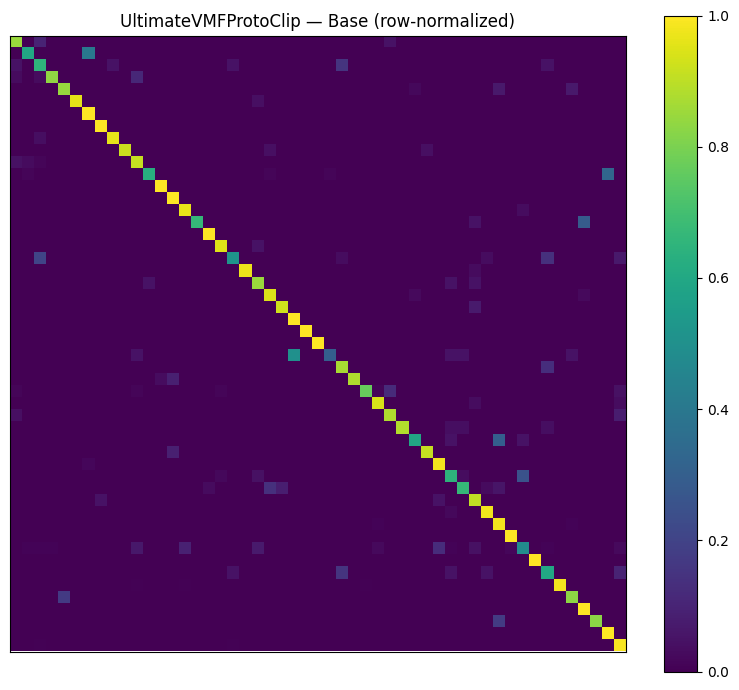

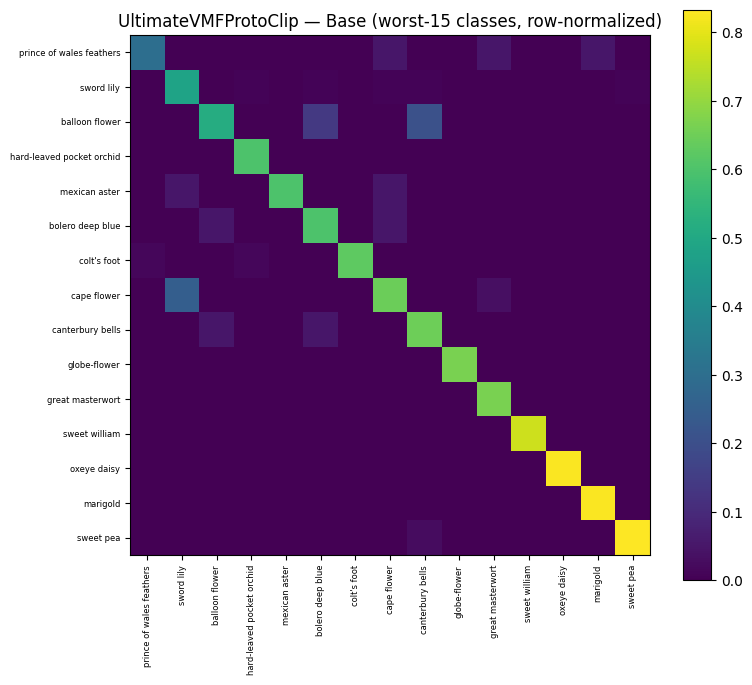

Top Base confusions (counts):


,true,pred,count
0,cape flower,sword lily,22
1,colt's foot,common dandelion,22
2,hard-leaved pocket orchid,moon orchid,16
3,sword lily,ruby-lipped cattleya,14
4,sword lily,yellow iris,10
5,prince of wales feathers,red ginger,10
6,sweet william,garden phlox,8
7,marigold,english marigold,8
8,sword lily,fire lily,8
9,sword lily,snapdragon,7


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[Novel] acc=77.48% | reject_rate=97.50%


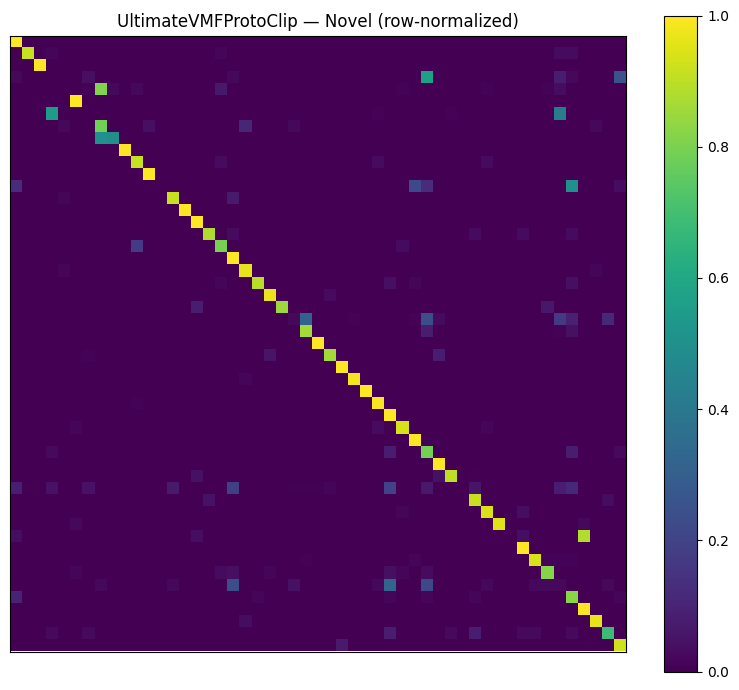

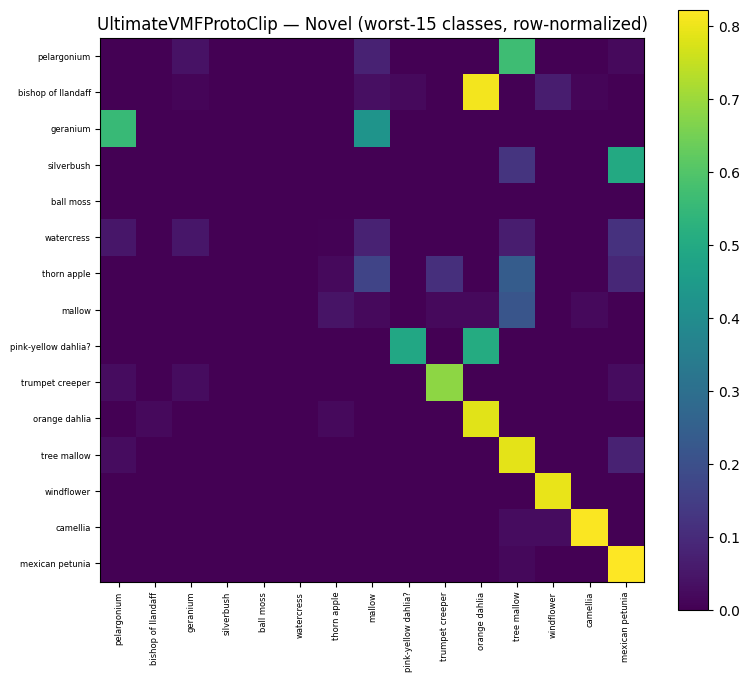

Top Novel confusions (counts):


,true,pred,count
0,bishop of llandaff,orange dahlia,72
1,geranium,pelargonium,52
2,pink-yellow dahlia?,orange dahlia,45
3,geranium,mallow,40
4,watercress,hibiscus,33
5,thorn apple,morning glory,32
6,watercress,tree poppy,31
7,pelargonium,tree mallow,29
8,thorn apple,tree mallow,24
9,ball moss,bromelia,23


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import pandas as pd

@torch.no_grad()
def _ensure_text_features(wrapper):
    # Base features exist after training; Novel features are computed in setup(stage="test")
    if not hasattr(wrapper, "text_features") or wrapper.text_features is None:
        wrapper.setup(stage=None)
    if not hasattr(wrapper, "novel_text_features"):
        wrapper.setup(stage="test")

@torch.no_grad()
def collect_predictions_for_split(wrapper, dataset, split: str, batch_size=128, num_workers=4, use_rejection=True):
    """
    Returns:
      y_true_contig: [N] in 0..50 (contiguous within split)
      y_pred_contig: [N] in 0..50 (contiguous within split)
      rejected_mask: [N] boolean (True if fallback-to-CLIP happened), or None if use_rejection=False
      class_ids: list of original class IDs for this split (length 51)
    """
    assert split in ("base", "novel")

    wrapper.eval()
    wrapper = wrapper.to(device)
    clip_model.eval()

    _ensure_text_features(wrapper)

    if split == "base":
        class_ids = list(wrapper.base_cat)
        text_features = wrapper.text_features
    else:
        class_ids = list(wrapper.novel_cat)
        text_features = wrapper.novel_text_features

    contig = {cid: i for i, cid in enumerate(class_ids)}
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    y_true, y_pred = [], []
    rejected_all = [] if use_rejection else None

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        # Map targets to contiguous indices within the split
        t_contig = torch.tensor([contig[int(t.item())] for t in targets], device=device, dtype=torch.long)

        # Frozen CLIP image features
        img_feat = clip_model.encode_image(images)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        # Head logits (51-way within split)
        model_out = wrapper.fine_tuning_model(img_feat)
        logits = model_out["logits"]

        # Optional rejection: replace low-confidence head logits with CLIP logits in the same label space
        if use_rejection and hasattr(wrapper, "logits_rejection_threshold"):
            clip_logits = img_feat @ text_features.t()
            max_logits, pred_classes = logits.max(dim=-1)
            thresholds = wrapper.logits_rejection_threshold[pred_classes]
            ood_mask = max_logits < thresholds
            logits = torch.where(ood_mask.unsqueeze(-1), clip_logits, logits)
            rejected_all.append(ood_mask.detach().cpu().numpy())

        preds = logits.argmax(dim=-1)

        y_true.append(t_contig.detach().cpu().numpy())
        y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    rejected_mask = np.concatenate(rejected_all) if rejected_all is not None and len(rejected_all) > 0 else None

    return y_true, y_pred, rejected_mask, class_ids

def plot_confusion(cm, title, class_names=None, show_ticks=False):
    cm = np.asarray(cm)
    fig = plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    if show_ticks and class_names is not None:
        plt.xticks(np.arange(len(class_names)), class_names, rotation=90, fontsize=6)
        plt.yticks(np.arange(len(class_names)), class_names, fontsize=6)
    else:
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()
    return fig

def top_confusions(cm_counts, class_names, top_k=15):
    cm = np.asarray(cm_counts).copy()
    np.fill_diagonal(cm, 0)
    flat = cm.flatten()
    idx = np.argpartition(flat, -top_k)[-top_k:]
    idx = idx[np.argsort(flat[idx])[::-1]]

    rows = []
    n = cm.shape[0]
    for id_flat in idx:
        i, j = divmod(int(id_flat), n)
        rows.append({
            "true": class_names[i],
            "pred": class_names[j],
            "count": int(cm[i, j]),
        })
    return pd.DataFrame(rows)

# Select the Ultimate wrapper
ultimate = None
if "UltimateVMFProtoClip_wrapper" in globals():
    ultimate = UltimateVMFProtoClip_wrapper
elif "loaded_wrappers" in globals() and "UltimateVMFProtoClip" in loaded_wrappers:
    ultimate = loaded_wrappers["UltimateVMFProtoClip"]

assert ultimate is not None, "Could not find an UltimateVMFProtoClip wrapper instance."

# Ensure rejection threshold is set
if "ultimate_rejection_thresholds" in globals():
    ultimate.set_logits_rejection_threshold(ultimate_rejection_thresholds)

# Base split confusion matrix
y_true_b, y_pred_b, rej_b, base_ids = collect_predictions_for_split(
    ultimate, test_base, split="base", use_rejection=True
)
base_names = [CLASS_NAMES[c] for c in base_ids]

cm_b = confusion_matrix(y_true_b, y_pred_b, labels=np.arange(len(base_ids)))
cm_b_norm = cm_b / np.clip(cm_b.sum(axis=1, keepdims=True), 1, None)

print(f"[Base] acc={np.mean(y_true_b==y_pred_b)*100:.2f}% | reject_rate={(rej_b.mean()*100 if rej_b is not None else 0):.2f}%")
plot_confusion(cm_b_norm, "UltimateVMFProtoClip — Base (row-normalized)", show_ticks=False)

# Zoom on worst classes (lowest diagonal in normalized CM)
diag_b = np.diag(cm_b_norm)
worst_idx_b = np.argsort(diag_b)[:15]
plot_confusion(
    cm_b_norm[np.ix_(worst_idx_b, worst_idx_b)],
    "UltimateVMFProtoClip — Base (worst-15 classes, row-normalized)",
    class_names=[base_names[i] for i in worst_idx_b],
    show_ticks=True
)

print("Top Base confusions (counts):")
display(top_confusions(cm_b, base_names, top_k=15))

# Novel split confusion matrix
y_true_n, y_pred_n, rej_n, novel_ids = collect_predictions_for_split(
    ultimate, test_novel, split="novel", use_rejection=True
)
novel_names = [CLASS_NAMES[c] for c in novel_ids]

cm_n = confusion_matrix(y_true_n, y_pred_n, labels=np.arange(len(novel_ids)))
cm_n_norm = cm_n / np.clip(cm_n.sum(axis=1, keepdims=True), 1, None)

print(f"[Novel] acc={np.mean(y_true_n==y_pred_n)*100:.2f}% | reject_rate={(rej_n.mean()*100 if rej_n is not None else 0):.2f}%")
plot_confusion(cm_n_norm, "UltimateVMFProtoClip — Novel (row-normalized)", show_ticks=False)

diag_n = np.diag(cm_n_norm)
worst_idx_n = np.argsort(diag_n)[:15]
plot_confusion(
    cm_n_norm[np.ix_(worst_idx_n, worst_idx_n)],
    "UltimateVMFProtoClip — Novel (worst-15 classes, row-normalized)",
    class_names=[novel_names[i] for i in worst_idx_n],
    show_ticks=True
)

print("Top Novel confusions (counts):")
display(top_confusions(cm_n, novel_names, top_k=15))


### Summary of Confusion Patterns
- Base split reaches 89.0% with a moderate rejection rate (35.5%): the remaining errors are mostly between visually similar species (e.g., sword lily vs other lilies/irises, marigold vs english marigold), so coarse separation is good while fine-grained distinctions remain hard.

- Novel split reaches 76.99% but with a very high rejection rate (97.01%): most novel samples fall back to CLIP; when the model does commit, confusions stay within closely related groups (dahlia variants, geranium/pelargonium/mallow/hibiscus, watercress vs related petunia/hibiscus).

### Qualitative confusion examples (Colt's foot vs Common dandelion)
Some flower pairs are hard to distinguish even for humans. A frequent confusion in our Base split is **colt’s foot** vs **common dandelion**. We display one test image from each class below to illustrate their similarity, which explains why this pair is one of the most frequently confused by the model.

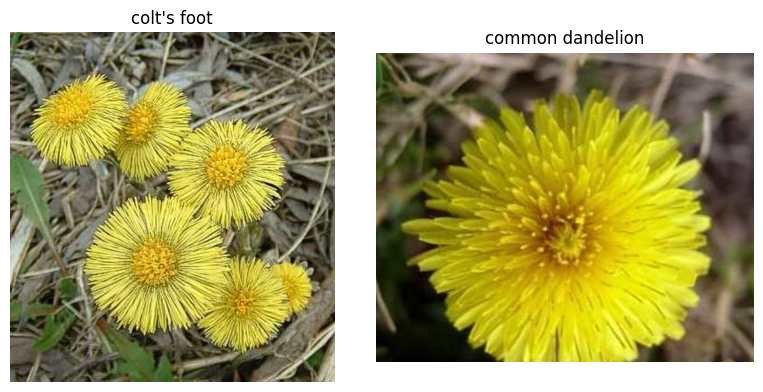

In [ ]:
import torchvision
import matplotlib.pyplot as plt

# Load raw test images (no preprocessing) for qualitative inspection
raw_test = torchvision.datasets.Flowers102(root=DATA_DIR, split="test", download=True, transform=None)

target_names = ["colt's foot", "common dandelion"]
target_ids = [CLASS_NAMES.index(name) for name in target_names]

def find_first_index(labels, target_id):
    for idx, lab in enumerate(labels):
        if lab == target_id:
            return idx
    return None

indices = [find_first_index(raw_test._labels, tid) for tid in target_ids]
images = [raw_test[i][0] for i in indices]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, img, name in zip(axes, images, target_names):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Performance Evolution Across Model Variants

We plot Base, Novel, and Harmonic Mean scores for each model variant to show how each change shifts performance:

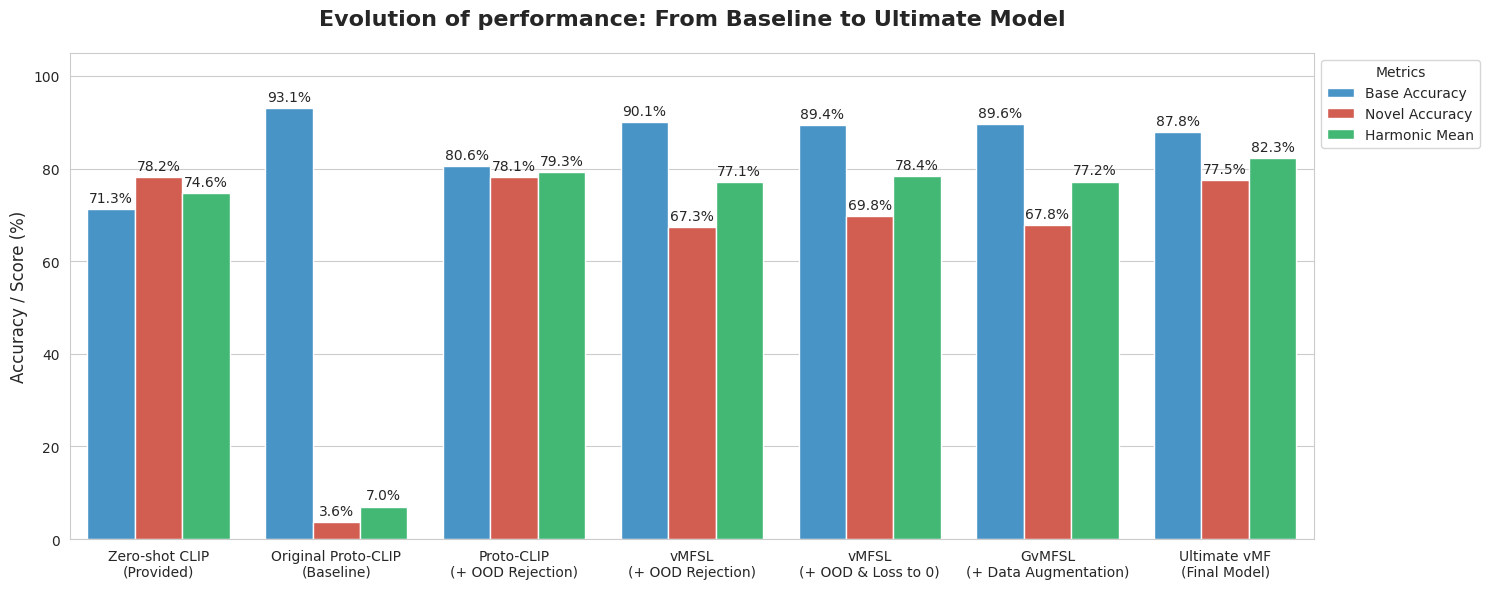

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = [
    "Zero-shot CLIP\n(Provided)",
    "Original Proto-CLIP\n(Baseline)",
    "Proto-CLIP\n(+ OOD Rejection)",
    "vMFSL\n(+ OOD Rejection)",
    "vMFSL\n(+ OOD & Loss to 0)",
    "GvMFSL\n(+ Data Augmentation)",
    "Ultimate vMF\n(Final Model)"
]

results_data = {
    "Model Variant": model_order,
    "Base Accuracy": [experiments_tracker[m]["base"] for m in model_order],
    "Novel Accuracy": [experiments_tracker[m]["novel"] for m in model_order],
    "Harmonic Mean": [experiments_tracker[m]["harmonic"] for m in model_order]
}

df_results = pd.DataFrame(results_data)
df_melted = df_results.melt(id_vars="Model Variant", var_name="Metric", value_name="Score")

# Setup plot
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# Create bar plot
ax = sns.barplot(
    data=df_melted,
    x="Model Variant",
    y="Score",
    hue="Metric",
    palette={"Base Accuracy": "#3498db", "Novel Accuracy": "#e74c3c", "Harmonic Mean": "#2ecc71"}
)

plt.title("Evolution of performance: From Baseline to Ultimate Model", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Accuracy / Score (%)", fontsize=12)
plt.xlabel("", fontsize=12)
plt.legend(title="Metrics", loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.ylim(0, 105)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()

plt.show()

# Ablation Study on the ultimate model

Having achieved our best performing model, we now need to understand **which components truly matter**. While we've iteratively added improvements throughout our experiments, we haven't systematically quantified the individual contribution of each component. By removing them one at a time from the final model, we can measure their impact on performance.

Our final `UltimateVMFProtoClip` model combines four key innovations:
1. **vMF architecture**: Von Mises-Fisher loss instead of Euclidean distance 
2. **Label smoothing**: Soft targets to prevent overconfidence
3. **Data augmentation**: RandAugment + Mixup for robustness
4. **OOD rejection**: Confidence-based fallback to CLIP for novel classes

Following standard ablation methodology, we start from the complete model and systematically remove each component, training from scratch with identical hyperparameters (36 epochs, same optimizer settings) to ensure fair comparison. We also test combinations of removals to detect potential interactions between components.

In [ ]:
# ==================== ABLATION STUDY ====================

# Define ablation configurations - starting from full model and removing pieces
ablation_configs = {
    # Full model (baseline for ablation)
    "Full Model": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": aug_train_loader_base,
        "loss_module": LRegLoss(0),  # CE + label smoothing, no dispersion reg
        "ood_rejection": True,
        "description": "Complete final model with all components"
    },

    # Remove OOD rejection
    "w/o OOD Rejection": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": aug_train_loader_base,
        "loss_module": LRegLoss(0),
        "ood_rejection": False,
        "description": "Remove OOD rejection mechanism"
    },

    # Remove data augmentation (RandAugment + Mixup)
    "w/o Data Augmentation": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": None,  # Use default loader without augmentation
        "loss_module": LRegLoss(0),
        "ood_rejection": True,
        "description": "Remove RandAugment and Mixup"
    },

    # Remove label smoothing
    "w/o Label Smoothing": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": aug_train_loader_base,
        "loss_module": None,  # Plain CE loss
        "ood_rejection": True,
        "description": "Remove label smoothing from loss"
    },

    # Remove multiple components at once
    "w/o Data Aug + OOD": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": None,
        "loss_module": LRegLoss(0),
        "ood_rejection": False,
        "description": "Remove both data augmentation and OOD rejection"
    },

    "w/o Data Aug + Label Smooth": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": None,
        "loss_module": None,
        "ood_rejection": True,
        "description": "Remove data augmentation and label smoothing"
    },

    # Minimal model (only vMF architecture)
    "Only vMF (Minimal)": {
        "model_class": UltimateVMFProtoClip,
        "train_loader": None,
        "loss_module": None,
        "ood_rejection": False,
        "description": "Only vMF architecture, no other improvements"
    }
}

# Store ablation results
ablation_results = {}

# Train and test each configuration
for config_name, config in ablation_configs.items():
    print(f"\n{'='*80}")
    print(f"Configuration: {config_name}")
    print(f"Description: {config['description']}")
    print(f"{'='*80}")

    # Skip if full model already trained
    if config_name == "Full Model" and "Ultimate vMF\n(Final Model)" in experiments_tracker:
        print("Using existing full model results...")
        ablation_results[config_name] = experiments_tracker["Ultimate vMF\n(Final Model)"]
        continue

    # Register model in dict
    model_key = f"Ablation_{config_name.replace(' ', '_').replace('/', '_')}"
    model_dict[model_key] = config["model_class"]

    # Train model
    wrapper = train_model(
        model_key,
        visual_cache_keys,
        txt_cache_keys,
        train_dataloader=config["train_loader"],
        loss_module=config["loss_module"],
        retrain_model=True,
        num_epochs=36  # Use consistent training duration
    )

    # Compute OOD thresholds if needed
    thresholds = None
    if config["ood_rejection"]:
        print("Computing OOD rejection thresholds...")
        thresholds = compute_epsilon_statistics(wrapper, clip_model)

    # Test model
    test_model(wrapper, logits_rejection_threshold=thresholds, experiment_name=config_name)

    # Store results
    ablation_results[config_name] = experiments_tracker[config_name]

print("\n" + "=" * 80)
print("ABLATION STUDY COMPLETED")
print("=" * 80)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'fine_tuning_model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['fine_tuning_model'])`.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'loss_module' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss


Configuration: Full Model
Description: Complete final model with all components
Using existing full model results...

Configuration: w/o OOD Rejection
Description: Remove OOD rejection mechanism


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models/Ablation_w_o_OOD_Rejection exists and is not empty.


Output()

=== Testing on base classes ===
📊 Base Accuracy:  91.99%
=== Testing on novel classes ===


...

INFO:lightning_fabric.utilities.seed:Seed set to 42


📊 Novel Accuracy: 78.18%
------------------------------
🔍 Harmonic Mean:  80.57%
------------------------------

Configuration: Only vMF (Minimal)
Description: Only vMF architecture, no other improvements


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models/Ablation_Only_vMF_(Minimal) exists and is not empty.


Output()

=== Testing on base classes ===
📊 Base Accuracy:  96.40%
=== Testing on novel classes ===
📊 Novel Accuracy: 3.37%
------------------------------
🔍 Harmonic Mean:  6.52%
------------------------------

ABLATION STUDY COMPLETED


<>:63: SyntaxWarning: invalid escape sequence '\+'
<>:63: SyntaxWarning: invalid escape sequence '\+'
/tmp/ipython-input-1433993551.py:63: SyntaxWarning: invalid escape sequence '\+'
  ~df_ablation["Configuration"].str.contains("\+")]
/tmp/ipython-input-1433993551.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


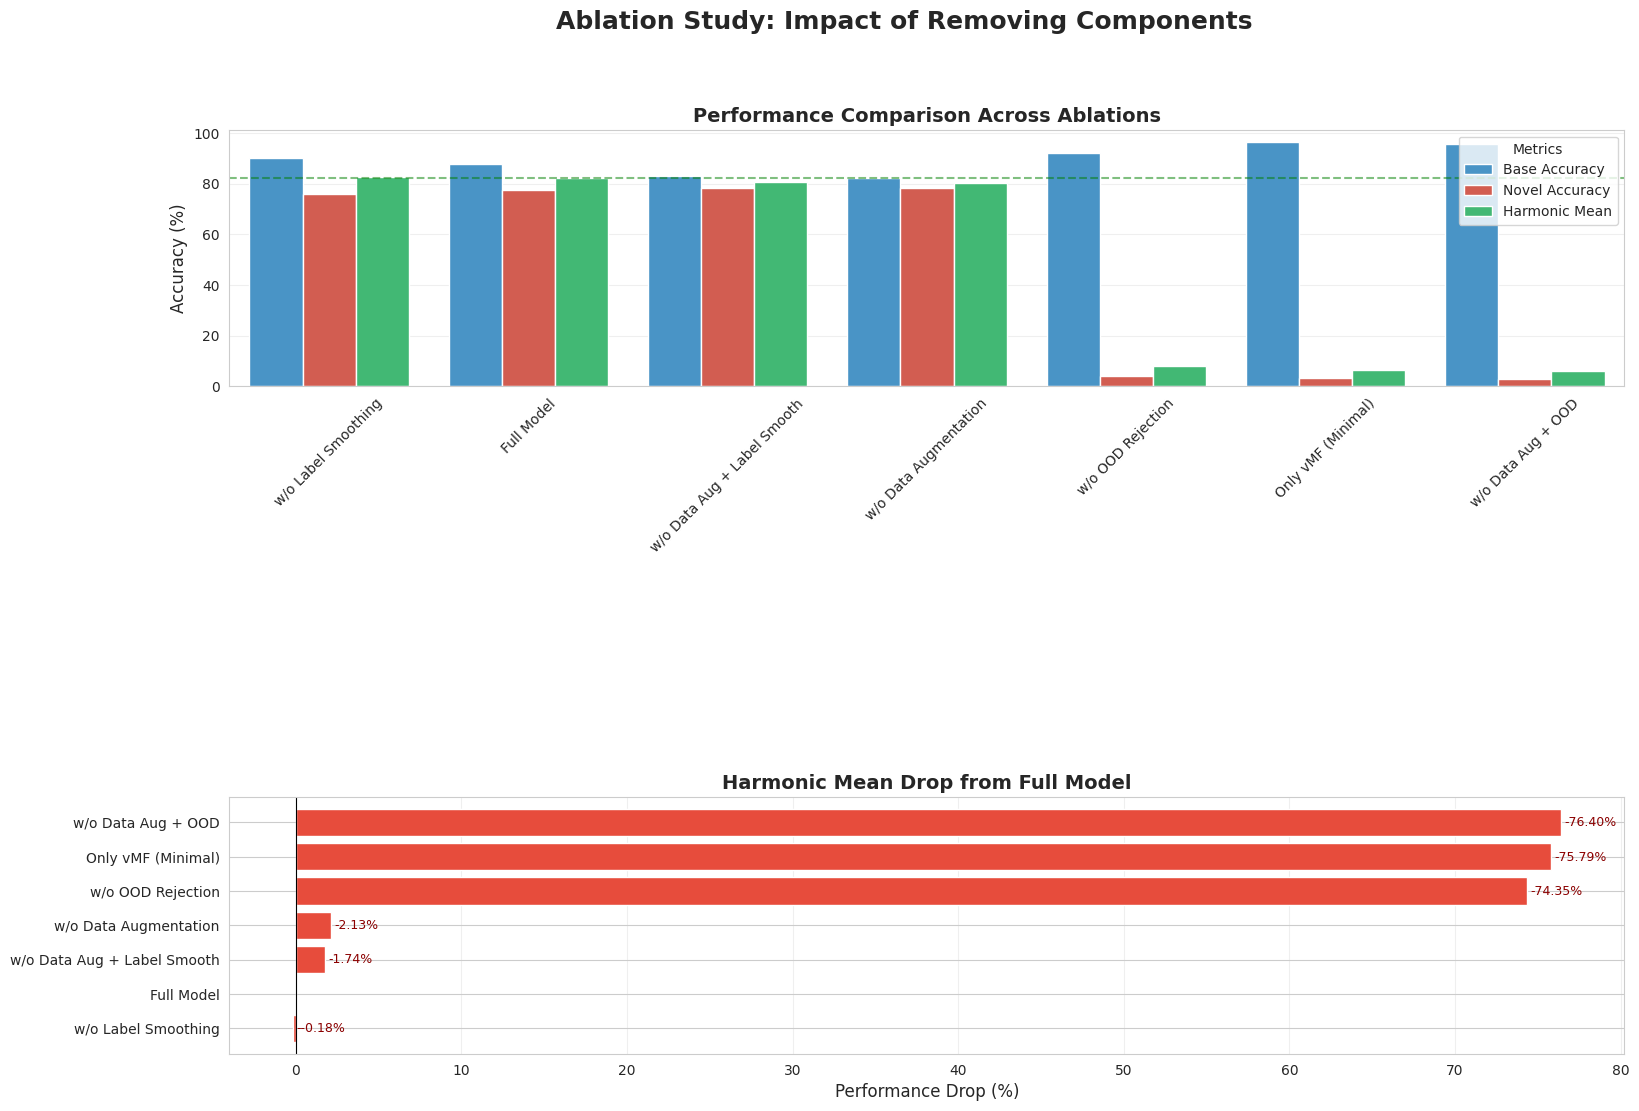


----------------------------------------------------------------------------------------------------
KEY FINDINGS:
----------------------------------------------------------------------------------------------------
• Most critical component: w/o OOD Rejection
  → Removing it causes 74.35% drop in harmonic mean

• Least critical component: w/o Label Smoothing
  → Removing it causes only -0.18% drop


In [ ]:
# ==================== ABLATION STUDY VISUALIZATION ====================

# Prepare ablation data
ablation_data = []
for config_name, results in ablation_results.items():
    ablation_data.append({
        "Configuration": config_name,
        "Base Accuracy": results["base"],
        "Novel Accuracy": results["novel"],
        "Harmonic Mean": results["harmonic"]
    })

df_ablation = pd.DataFrame(ablation_data)

# Get full model performance as reference
full_model_hm = ablation_results["Full Model"]["harmonic"]

# Calculate performance drop for each ablation
df_ablation["HM Drop"] = full_model_hm - df_ablation["Harmonic Mean"]

# Sort by harmonic mean (descending)
df_ablation = df_ablation.sort_values("Harmonic Mean", ascending=False)

# Create comprehensive ablation visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 1, hspace=0.3, wspace=0.3)

fig.suptitle("Ablation Study: Impact of Removing Components", fontsize=18, fontweight='bold')

# 1. Main comparison - All metrics
ax1 = fig.add_subplot(gs[0, :])
df_melted = df_ablation.melt(
    id_vars="Configuration",
    value_vars=["Base Accuracy", "Novel Accuracy", "Harmonic Mean"],
    var_name="Metric",
    value_name="Score"
)
sns.barplot(data=df_melted, x="Configuration", y="Score", hue="Metric", ax=ax1,
            palette={"Base Accuracy": "#3498db", "Novel Accuracy": "#e74c3c", "Harmonic Mean": "#2ecc71"})
ax1.set_title("Performance Comparison Across Ablations", fontsize=14, fontweight='bold')
ax1.set_xlabel("")
ax1.set_ylabel("Accuracy (%)", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.legend(title="Metrics", loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=full_model_hm, color='green', linestyle='--', alpha=0.5, label='Full Model HM')

# 2. Performance drop from full model
ax2 = fig.add_subplot(gs[2, 0])
colors = ['green' if x == 0 else '#e74c3c' for x in df_ablation["HM Drop"]]
bars = ax2.barh(df_ablation["Configuration"], df_ablation["HM Drop"], color=colors)
ax2.set_title("Harmonic Mean Drop from Full Model", fontsize=14, fontweight='bold')
ax2.set_xlabel("Performance Drop (%)", fontsize=12)
ax2.set_ylabel("")
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
for i, (config, drop) in enumerate(zip(df_ablation["Configuration"], df_ablation["HM Drop"])):
    if drop != 0:
        ax2.text(drop + 0.2, i, f"-{drop:.2f}%", va='center', fontsize=9, color='darkred')
ax2.grid(axis='x', alpha=0.3)

# Calculate relative importance by comparing single-component removals
single_removals = df_ablation[df_ablation["Configuration"].str.startswith("w/o") &
                               ~df_ablation["Configuration"].str.contains("\+")]
single_removals = single_removals.sort_values("HM Drop", ascending=True)

plt.tight_layout()
plt.show()

print("\n" + "-" * 100)
print("KEY FINDINGS:")
print("-" * 100)

# Find most impactful single component
most_critical = single_removals.iloc[-1]
print(f"• Most critical component: {most_critical['Configuration']}")
print(f"  → Removing it causes {most_critical['HM Drop']:.2f}% drop in harmonic mean")

# Find least impactful
least_critical = single_removals.iloc[0]
print(f"\n• Least critical component: {least_critical['Configuration']}")
print(f"  → Removing it causes only {least_critical['HM Drop']:.2f}% drop")

print("=" * 100)

## Ablation Study and Takeaways

The ablation results help isolate which ingredients matter most for Base and Novel performance.

**OOD rejection (most critical):** Removing it causes a 73.68% drop in HM, essentially collapsing Novel performance. Without rejection, the fine tuned model becomes fully specialized to Base classes. The epsilon threshold mechanism is what preserves CLIP generalization.

**Data augmentation (moderately important):** Removing augmentation alone yields a 2.07% drop, suggesting that augmentation helps calibrate the confidence scores that OOD rejection relies on. The combined removal ("w/o Data Aug + OOD") results in a 76.50% drop.

**Label smoothing (counterproductive):** Without label smoothing, HM improves by 0.53%. This is also consistent with the minimal model ("Only vMF"), which shows a 75.03% HM drop, while adding label smoothing on top ("w/o Data Aug + OOD") degrades further to 76.50%.

### Key Observations

The dominant failure mode is the Base-Novel trade off. **OriginalProtoClip without rejection** achieves 95.15% Base but only 3.62% Novel (HM 6.97%), which is a clear sign of strong Base specialization with poor transfer.

Once **confidence based rejection** is enabled, the balance changes substantially. **OriginalProtoClip** reaches 86.09% Base and 77.67% Novel (HM 81.66%), while **vMFSLProtoClip** yields 89.16% Base and 68.20% Novel (HM 77.28%).

**UltimateVMFProtoClip** achieves the best overall balance at 89.00% Base and 76.99% Novel, with HM 82.56%.


## Conclusions

We explored few shot adaptation for Base to Novel generalization on Flowers102 with a frozen CLIP backbone. A purely Base focused adaptation can distort the representation space toward the seen classes, which helps Base accuracy but harms transfer.

Our best results come from treating adaptation as a selective prediction problem. We combine a prototype based head, a von Mises Fisher objective inspired by SphOR [[1](https://arxiv.org/abs/2503.08049)], and a simple confidence based rejection rule that falls back to vanilla CLIP when the adapted head is not confident enough.

**Our main finding** is that the most reliable gains do not come from pushing the adapted head to be uniformly stronger, but from using it only when it is trustworthy. Data augmentation helps by stabilizing the cache and improving confidence calibration, while label smoothing consistently hurts in this setting.

Overall, **UltimateVMFProtoClip** gives the best Base-Novel balance in our experiments. The remaining errors are mostly fine-grained confusions, which are difficult to resolve with only 10 shot supervision.

Future work could explore numerically stable approximations for the Bhattacharyya coefficient to quantify class separability in high dimensional embeddings.

## Bibliography

[1] N. Bahavan, S. Seneviratne, and S. Halgamuge, “SphOR: A Representation Learning Perspective on Open-set Recognition for Identifying Unknown Classes in Deep Learning Models,” Mar. 19, 2025, arXiv: arXiv:2503.08049. doi: 10.48550/arXiv.2503.08049.


[2] S. Sra, “A short note on parameter approximation for von Mises-Fisher distributions: and a fast implementation of I s (x),” Comput Stat, vol. 27, no. 1, pp. 177-190, Mar. 2012, doi: 10.1007/s00180-011-0232-x.

[3] J. J. P, K. Palanisamy, Y.-W. Chao, X. Du, and Y. Xiang, “Proto-CLIP: Vision-Language Prototypical Network for Few-Shot Learning,” Jul. 14, 2024, arXiv: arXiv:2307.03073. doi: 10.48550/arXiv.2307.03073.

[4] T. Kitagawa and J. Rowley, “von Mises-Fisher distributions and their statistical divergence,” Nov. 19, 2022, arXiv: arXiv:2202.05192. doi: 10.48550/arXiv.2202.05192.

[5] R. Zhang et al., “Tip-Adapter: Training-free CLIP-Adapter for Better Vision-Language Modeling,” Nov. 15, 2021, arXiv: arXiv:2111.03930. doi: 10.48550/arXiv.2111.03930.
